## Preliminary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\FUFA Code\\Match-Analysis\\data\\processed\\UPL_25_26_mid_season_matches_cleaned.csv')

In [2]:
#FUFA Brand Colours
mid_blue = '#353b91'
dark_blue = '#333d92'
white = '#ffffff'
light_blue = '#007bc1'
black = '#000000'
red = '#e00024'
yellow = '#f8f400'

# FUFA Brand Color Palette
FUFA_COLORS = {
    'primary_dark': dark_blue,
    'primary_mid': mid_blue,
    'primary_light': light_blue,
    'accent_red': red,
    'accent_yellow': yellow,
    'neutral_white': white,
    'neutral_black': black,
}

FUFA_CHART_PALETTE = [dark_blue, light_blue, '#5B7DA3', '#8FA3C1']

def apply_fufa_chart_theme(ax, remove_y_labels=False, remove_y_ticks=False, remove_x_labels=False):
    """Apply professional FUFA brand styling to chart axes with creative enhancements."""
    # Spine styling - minimal but present
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D0D0D0')
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_color('#D0D0D0')
    ax.spines['bottom'].set_linewidth(0.8)
    
    # Grid - subtle, professional appearance
    ax.yaxis.grid(True, linestyle='-', alpha=0.15, color='#808080', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Axis management
    if remove_y_labels:
        ax.set_yticklabels([])
    if remove_y_ticks:
        ax.set_yticks([])
    if remove_x_labels:
        ax.set_xticklabels([])
    
    # Professional tick styling - not bold, just readable
    ax.tick_params(labelsize=8.5, colors='#404040')
    ax.xaxis.label.set_fontsize(9.5)
    ax.yaxis.label.set_fontsize(9.5)

def apply_professional_style(ax, title: str, xlabel: str = '', ylabel: str = ''):
    """Apply professional FUFA brand styling with creative enhancements."""
    apply_fufa_chart_theme(ax)
    
    # Title - bold and prominent
    ax.set_title(title, fontsize=13, fontweight='bold', pad=18, color=dark_blue)
    
    # Axis labels - regular weight, darker color for contrast
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9.5, fontweight='400', color='#1F1F1F')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9.5, fontweight='400', color='#1F1F1F')
    
    # Tick styling
    ax.tick_params(axis='x', labelsize=8.5, colors='#404040')
    ax.tick_params(axis='y', labelsize=8.5, colors='#404040')

In [3]:
df.shape

(1872, 89)

In [4]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']


In [5]:
df['match_day'] = df['match_day'].str.replace('Wmd', 'MD')

In [6]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled


In [7]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)


In [8]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

In [9]:
df['p_name'].nunique()

309

## Summary

In [10]:
summary_table_intensity = df[intensity_metrics].agg(['max', 'mean', 'std']).T
style_table_for_docs(summary_table_intensity.round(2))

,max,mean,std
player_load,639.950000,403.120000,96.830000
top_speed_kmh,35.700000,29.930000,2.140000
distance_per_min_mmin,141.240000,90.110000,23.450000
power_score_wkg,8.770000,4.510000,1.580000
work_ratio,48.000000,23.300000,8.750000
max_acceleration_mss,10.000000,5.880000,0.620000
max_deceleration_mss,10.000000,7.250000,1.000000
acc_counts_per_min,6.630000,4.170000,1.160000
dec_counts_per_min,6.640000,4.000000,1.130000


In [11]:
summary_table_volume = df[volume_metrics].agg(['sum','mean', 'std']).T
style_table_for_docs(summary_table_volume.round(2))

,sum,mean,std
distance_km,16467.850000,8.800000,2.290000
sprint_distance_m,1591522.160000,850.170000,368.850000
power_plays,118977.000000,63.560000,22.660000
energy_kcal,2027655.490000,1083.150000,291.730000
impacts,12537.000000,6.700000,5.160000
total_accelerations,762196.000000,407.160000,113.180000
total_decelerations,731703.000000,390.870000,109.770000


## Data Overview

In [12]:
unique_players_per_club = df.groupby('club_for')['p_name'].nunique().reset_index()
unique_players_per_club.columns = ['club_for', 'unique_players']
style_table_for_docs(unique_players_per_club.sort_values(by='unique_players', ascending=False))

,club_for,unique_players
6,Lugazi Fc,26
9,Nec Fc,26
4,Kcca Fc,24
13,Ura Fc,24
2,Calvary Fc,24
1,Bul Fc,22
12,Updf Fc,22
7,Maroons Fc,21
14,Vipers Sc,20
8,Mbarara City Fc,20


In [13]:
# Calculate average number of unique players per matchday for each club
players_per_club_day = df.groupby(['club_for', 'match_day'])['p_name'].nunique().reset_index()
avg_players_per_matchday = players_per_club_day.groupby('club_for')['p_name'].mean().reset_index()
avg_players_per_matchday.columns = ['club_for', 'avg_players_per_matchday']
style_table_for_docs(avg_players_per_matchday.sort_values(by='avg_players_per_matchday', ascending=False))

,club_for,avg_players_per_matchday
13,Ura Fc,12.866667
9,Nec Fc,11.000000
7,Maroons Fc,10.666667
2,Calvary Fc,10.071429
12,Updf Fc,9.866667
8,Mbarara City Fc,9.846154
3,Entebbe Uppc Fc,9.066667
4,Kcca Fc,8.733333
0,Buhimba United Saints Fc,8.000000
6,Lugazi Fc,7.866667


In [14]:
# Count the number of unique matchdays for each club
unique_matchdays_per_club = df.groupby('club_for')['match_day'].nunique().reset_index()
unique_matchdays_per_club.columns = ['club_for', 'unique_matchdays']
style_table_for_docs(unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False))

,club_for,unique_matchdays
1,Bul Fc,15
4,Kcca Fc,15
3,Entebbe Uppc Fc,15
6,Lugazi Fc,15
13,Ura Fc,15
9,Nec Fc,15
7,Maroons Fc,15
12,Updf Fc,15
11,Sc Villa,14
2,Calvary Fc,14


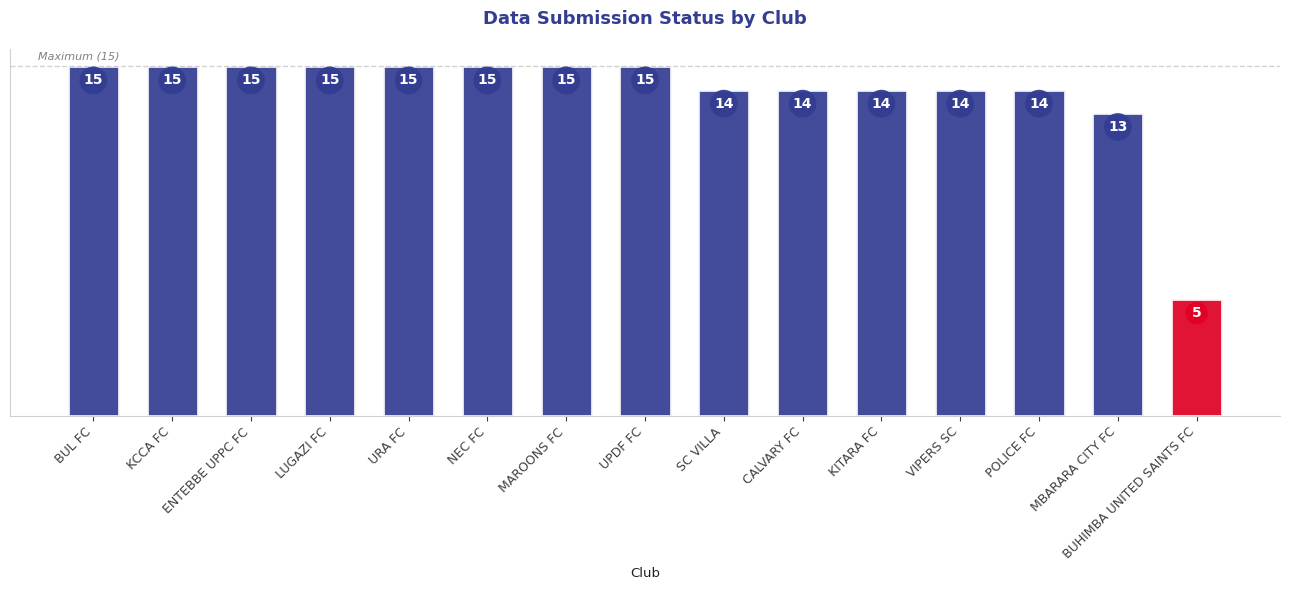

In [15]:
# Sort data
data = unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False)

# Define usage tiers and corresponding FUFA brand colors
def usage_tier_color(val):
    if val >= 10:
        return dark_blue  # FUFA primary dark blue for high engagement
    elif val >=8 :
        return light_blue  # FUFA light blue for medium
    else:
        return red  # FUFA red for low

colors = data['unique_matchdays'].map(usage_tier_color).tolist()

# Create professional barplot with creative styling
fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')

# Narrower bars with white edges for professional appearance
bars = ax.bar(
    range(len(data)), data['unique_matchdays'],
    color=colors, edgecolor='white', linewidth=2, alpha=0.92, width=0.65
)

# Benchmark line - subtle reference
ax.axhline(15, color='#A9A9A9', linestyle='--', linewidth=1, alpha=0.5)
ax.text(-0.7, 15.3, 'Maximum (15)', color='#808080', fontsize=8, style='italic', fontweight='400')

# Professional axis styling
apply_professional_style(ax, 'Data Submission Status by Club', 'Club', '')
ax.set_xticks(range(len(data)))
ax.set_xticklabels([name.upper() for name in data['club_for']], rotation=45, ha='right', fontsize=9, fontweight='400')

# Remove y-axis for cleaner look
ax.set_yticks([])
ax.set_yticklabels([])

# Annotate values with professional styling
for i, value in enumerate(data['unique_matchdays']):
    ax.text(
        i, value - 0.6, str(int(value)),
        ha='center', va='center',
        fontsize=10, color='white', fontweight='600',
        bbox=dict(boxstyle='circle,pad=0.3', edgecolor='none', facecolor=colors[i], alpha=0.95)
    )

plt.tight_layout()
plt.show()

In [16]:
# uploaded_matches = {
#     "She Maroons FC": 20,
#     "Kawempe Muslim LFC": 22,
#     "Uganda Martyrs Lubaga WFC": 18,
#     "Rines SS WFC": 22,
#     "Amus College WFC": 19,
#     "Wakiso Hill WFC": 18,
#     "Lady Doves FC": 16,
#     "Makerere University WFC": 22,
#     "Kampala Queens FC": 17,
#     "Olila HS WFC": 13,
#     "She Corporates FC": 5,
#     "FC Tooro Queens": 0,
    
# }

# uploaded_matches_df = pd.DataFrame(uploaded_matches.items(), columns=['club_for', 'uploaded_matches'])
# uploaded_matches_df['club_for'] = uploaded_matches_df['club_for'].str.title()

# uploaded_matches_df=uploaded_matches_df.merge(unique_matchdays_per_club, on='club_for', how='left').sort_values(by='unique_matchdays', ascending=False)
# uploaded_matches_df = uploaded_matches_df.rename(columns={
#     'uploaded_matches': 'Uploaded Matchdays',
#     'unique_matchdays': 'Analysed Matchdays',
# })

In [17]:

# # Prepare DataFrame
# uploaded_matches_df_copy = uploaded_matches_df.copy()
# uploaded_matches_df_copy['Analysed']      = uploaded_matches_df_copy['Analysed Matchdays']
# uploaded_matches_df_copy['Pending']       = uploaded_matches_df_copy['Uploaded Matchdays'] - uploaded_matches_df_copy['Analysed Matchdays']
# uploaded_matches_df_copy['not_uploaded']  = 22 - uploaded_matches_df_copy['Uploaded Matchdays']
# uploaded_matches_df_copy = uploaded_matches_df_copy.sort_values('Analysed Matchdays', ascending=False)

# # Lighter color palette
# colors = {
#     'Analysed':      "#38759e",  # softer blue
#     'Pending':       "#ee9d50",  # softer orange
#     'not_uploaded':  "#f8373a"   # softer red
# }

# fig, ax = plt.subplots(figsize=(12,6))
# x = np.arange(len(uploaded_matches_df_copy))

# # Plot segments
# ax.bar(x, uploaded_matches_df_copy['Analysed'],
#        color=colors['Analysed'],
#        label='Analysed')
# ax.bar(x, uploaded_matches_df_copy['Pending'],
#        bottom=uploaded_matches_df_copy['Analysed'],
#        color=colors['Pending'],
#        label='Uploaded – Not Analysed')
# ax.bar(x, uploaded_matches_df_copy['not_uploaded'],
#        bottom=uploaded_matches_df_copy['Analysed'] + uploaded_matches_df_copy['Pending'],
#        color=colors['not_uploaded'],
#        label='Not Uploaded')

# # Benchmark line
# ax.axhline(22, color='gray', linestyle='--', linewidth=1)
# ax.text(-0.5, 22.5, 'MAXIMUM (22)', color='gray', fontsize=9)

# # X labels
# ax.set_xticks(x)
# ax.set_xticklabels(uploaded_matches_df_copy['club_for'].str.upper(), rotation=90, fontsize=9)

# # Clean Y axis
# ax.set_yticks([])
# ax.set_ylabel('')

# # Titles
# ax.set_xlabel('CLUB', fontsize=11)
# ax.set_title('MATCHDAY COVERAGE PER CLUB', fontsize=14, fontweight='bold',pad='30')

# # Gridlines
# ax.yaxis.grid(True, linestyle='--', alpha=0.5)
# ax.set_axisbelow(True)

# # Remove spines
# sns.despine(ax=ax, left=True, top=True, right=True)

# # Annotation helper
# def draw_circle_text(xpos, ypos, txt, color):
#     ax.text(
#         xpos, ypos, str(int(txt)),
#         ha='center', va='center', color='black',
#         fontsize=8, fontweight='bold',
#         bbox=dict(boxstyle="circle,pad=0.3", facecolor='white', edgecolor='none')
#     )

# # Annotate segments
# for idx, row in enumerate(uploaded_matches_df_copy.itertuples()):
#     analysed = row.Analysed
#     pending  = row.Pending
#     notup    = row.not_uploaded

#     # Analysed (always)
#     if analysed > 0:
#         draw_circle_text(idx, analysed / 2, analysed, colors['Analysed'])

#     # Pending (always)
#     if pending > 1:
#         draw_circle_text(idx, analysed + pending / 2, pending, colors['Pending'])

#     # not_uploaded (only if > 1)
#     if notup > 1:
#         ypos = analysed + pending + notup / 2
#         draw_circle_text(idx, ypos, notup, colors['not_uploaded'])

# # Legend outside
# ax.legend(
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0,
#     frameon=False
# )

# plt.tight_layout()
# plt.show()


In [18]:
# import matplotlib.patches as mpatches

# # 1. Get sorted lists of clubs & matchdays
# clubs = sorted(df['club_for'].unique())

# # Sort matchdays in correct order: MD1, MD2, ..., MD22
# matchday_order = [f'MD{i}' for i in range(1, 23)]
# matchdays = [md for md in matchday_order if md in df['match_day'].unique()]

# # 2. Build a binary grid (1 = analysed, 0 = missing)
# grid_data = []
# for md in matchdays:
#     row = []
#     for club in clubs:
#         mask = (df['match_day'] == md) & (df['club_for'] == club)
#         is_present = 1 if df.loc[mask, 'p_name'].nunique() > 0 else 0
#         row.append(is_present)
#     grid_data.append(row)

# # 3. Convert to DataFrame
# grid_df = pd.DataFrame(grid_data, index=matchdays, columns=clubs)

# # 4. Define colors
# color_map = {1: '#5cb85c', 0: '#d9534f'}  # green = uploaded, red = missing

# # 5. Plot
# fig, ax = plt.subplots(figsize=(len(clubs)*0.6 + 2, len(matchdays)*0.4 + 2))

# for y, md in enumerate(matchdays):
#     for x, club in enumerate(clubs):
#         val = grid_df.loc[md, club]
#         color = color_map[val]
#         rect = plt.Rectangle((x, y), 1, 1, facecolor=color, edgecolor='white')
#         ax.add_patch(rect)

# # 6. Axis Labels
# ax.set_xticks(np.arange(len(clubs)) + 0.5)
# ax.set_xticklabels([c.upper() for c in clubs], rotation=90, fontsize=9)
# ax.set_yticks(np.arange(len(matchdays)) + 0.5)
# ax.set_yticklabels([i.upper() for i in matchdays], fontsize=9)

# ax.set_xlim(0, len(clubs))
# ax.set_ylim(0, len(matchdays))
# ax.invert_yaxis()

# ax.set_xlabel('Club', fontsize=11)
# ax.set_ylabel('Match Day', fontsize=11)
# ax.set_title('Matchdays Analysed per Club', fontsize=13, fontweight='bold')

# # 7. Legend
# handles = [
#     mpatches.Patch(color=color_map[1], label='Analysed Matchday'),
#     mpatches.Patch(color=color_map[0], label='Missing Matchday')
# ]
# ax.legend(handles=handles, title='Color Map', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

# plt.tight_layout()
# plt.show()


In [19]:
# Calculate total player entries per matchday across all clubs
total_players_per_matchday = df.groupby('match_day',observed=False)['p_name'].count().reset_index()
total_players_per_matchday.columns = ['match_day', 'total_player_entries']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 16)]
total_players_per_matchday['match_day'] = pd.Categorical(
    total_players_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(total_players_per_matchday.sort_values(by='match_day'))

,match_day,total_player_entries
0,Md1,135
7,Md2,98
8,Md3,128
9,Md4,145
10,Md5,133
11,Md6,127
12,Md7,123
13,Md8,128
14,Md9,132
1,Md10,123


In [20]:
# Count the number of unique clubs that submitted data per matchday
clubs_per_matchday = df.groupby('match_day',observed=False)['club_for'].nunique().reset_index()
clubs_per_matchday.columns = ['match_day', 'num_clubs']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 16)]
clubs_per_matchday['match_day'] = pd.Categorical(
    clubs_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(clubs_per_matchday.sort_values(by='match_day'))


,match_day,num_clubs
0,Md1,15
7,Md2,13
8,Md3,15
9,Md4,15
10,Md5,15
11,Md6,14
12,Md7,13
13,Md8,14
14,Md9,14
1,Md10,14


In [21]:
def plot_line_with_values(data, x_col, y_col, title=None, x_label=None, y_label=None, figsize=(11, 5.5), line_color=None):
    """Create a professional FUFA-branded line chart with value annotations."""
    
    if line_color is None:
        line_color = dark_blue
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    
    # Sort data if match_day
    if x_col == 'match_day':
        data = data.copy()
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data = data.sort_values(by=x_col)
    
    # Plot the line with professional styling
    ax.plot(range(len(data)), data[y_col].values, marker='o', color=line_color, linewidth=2.5, 
            markersize=7, markerfacecolor='white', markeredgecolor=line_color, markeredgewidth=2.5)
    
    # Apply FUFA theme
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    
    # Set x-axis labels
    if x_col == 'match_day':
        xticklabels = [str(md).replace('Md', 'MD') for md in data[x_col]]
        ax.set_xticks(range(len(data)))
        ax.set_xticklabels(xticklabels, rotation=0, fontsize=9)
    
    # Add value labels above each point with professional styling
    for i, (x, y) in enumerate(zip(range(len(data)), data[y_col])):
        ax.annotate(
            f'{int(y) if y == int(y) else y:.1f}', 
            (x, y),
            textcoords='offset points', 
            xytext=(0, 10), 
            ha='center',
            fontsize=8,
            color='black',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', edgecolor=light_blue, facecolor='white', linewidth=1.2, alpha=0.95)
        )
    
    # Titles and labels
    if title is None:
        title = f'{y_col.replace("_", " ").title()} vs {x_col.replace("_", " ").title()}'
    ax.set_title(title, fontsize=12, fontweight='700', pad=15)
    
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    ax.set_xlabel(x_label, fontsize=10, fontweight='600')
    
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    ax.set_ylabel(y_label, fontsize=10, fontweight='600')
    
    plt.tight_layout()
    return ax


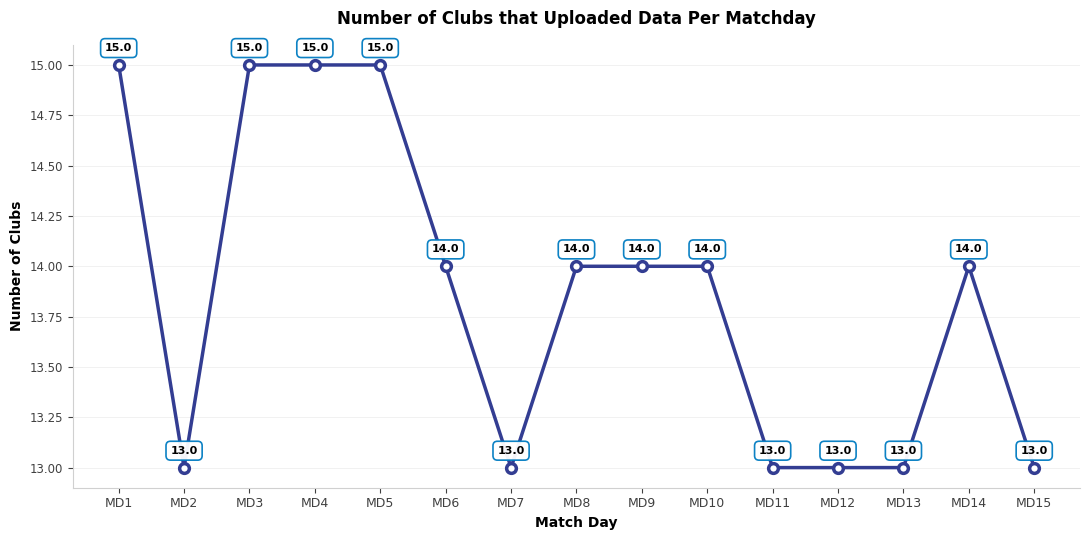

In [22]:
plot_line_with_values(clubs_per_matchday, 'match_day', 'num_clubs', title='Number of Clubs that Uploaded Data Per Matchday',x_label='Match Day', y_label='Number of Clubs');

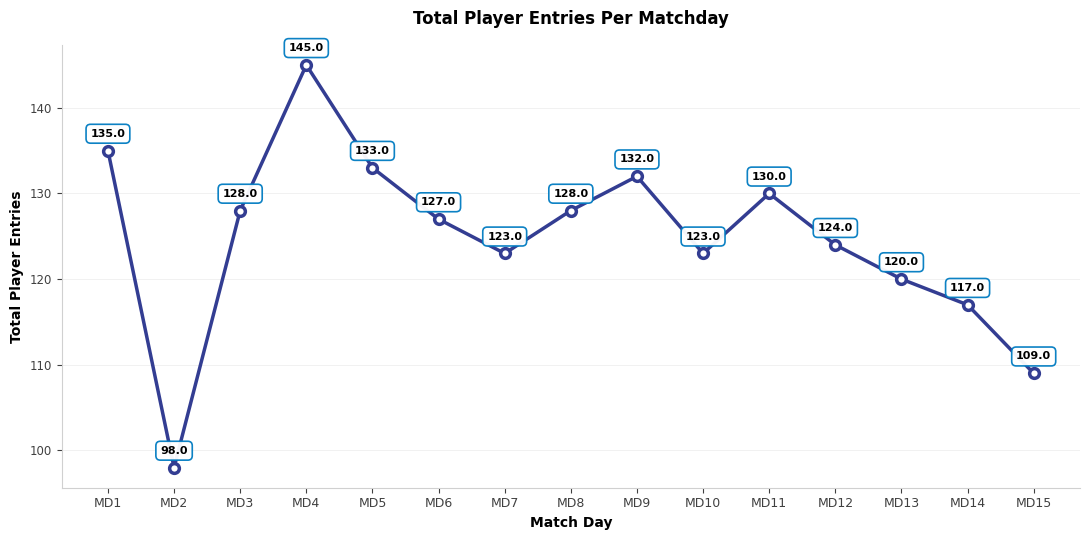

In [23]:
plot_line_with_values(total_players_per_matchday, 'match_day', 'total_player_entries', title='Total Player Entries Per Matchday', x_label='Match Day', y_label='Total Player Entries');

In [24]:
# # Count number and percentage of entries based on 'location'
# location_counts = df['location'].value_counts().reset_index()
# location_counts.columns = ['location', 'count']
# location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

# style_table_for_docs(location_counts)

In [25]:
# # Count number and percentage of entries based on 'result'
# location_counts = df['result'].value_counts().reset_index()
# location_counts.columns = ['result', 'count']
# location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

# style_table_for_docs(location_counts)

In [26]:
# Calculate Win-Draw-Loss counts for each club using unique match days
matchday_results = df.groupby(['club_for', 'match_day'])['result'].first().reset_index()
wld_counts = matchday_results.groupby(['club_for', 'result']).size().unstack(fill_value=0)
wld_counts = wld_counts[['Win', 'Draw', 'Loss']]  # Ensure order if all present

style_table_for_docs(wld_counts.sort_values(by='Win', ascending=False))


result,Win,Draw,Loss
club_for,,,
Vipers Sc,11,3,0
Kitara Fc,10,1,3
Entebbe Uppc Fc,9,3,3
Kcca Fc,9,3,3
Sc Villa,8,3,3
Police Fc,7,4,3
Bul Fc,6,3,6
Nec Fc,4,8,3
Maroons Fc,4,6,5


### Max Metrics

## Analysis

### Club Comparison

In [27]:
club_metrics_mean = (
    df.groupby(['club_for', 'match_day'],observed=False)[volume_metrics+intensity_metrics].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_distance_km', ascending=False)
    .reset_index()
)
style_table_for_docs(club_metrics_mean.round(2).T)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
club_for,Sc Villa,Entebbe Uppc Fc,Lugazi Fc,Kcca Fc,Police Fc,Kitara Fc,Buhimba United Saints Fc,Bul Fc,Calvary Fc,Vipers Sc,Maroons Fc,Updf Fc,Nec Fc,Ura Fc,Mbarara City Fc
avg_distance_km,10.130000,9.860000,9.720000,9.570000,9.510000,9.480000,9.210000,8.980000,8.930000,8.450000,8.400000,8.390000,7.970000,7.970000,7.890000
avg_sprint_distance_m,1081.760000,975.230000,812.290000,813.290000,995.470000,826.270000,749.380000,759.630000,931.640000,833.590000,872.120000,853.870000,766.260000,801.380000,762.820000
avg_power_plays,72.620000,77.320000,65.730000,68.730000,70.390000,61.170000,56.890000,60.980000,65.590000,63.740000,65.780000,59.590000,57.880000,57.890000,57.400000
avg_energy_kcal,1228.090000,1193.550000,1173.830000,1140.330000,1186.390000,1157.420000,1109.420000,1139.880000,1053.380000,1077.310000,1049.540000,1002.410000,1006.120000,1017.330000,987.830000
avg_impacts,7.780000,5.890000,7.330000,8.110000,8.870000,6.820000,9.630000,7.060000,4.830000,8.620000,5.320000,6.130000,6.770000,5.960000,5.740000
avg_total_accelerations,449.640000,444.540000,458.120000,455.450000,436.520000,438.030000,448.040000,422.870000,406.770000,406.110000,368.400000,372.010000,384.020000,375.730000,376.330000
avg_total_decelerations,428.470000,424.450000,435.420000,434.960000,421.720000,420.220000,427.350000,404.790000,390.820000,391.190000,355.870000,360.530000,368.000000,358.980000,363.930000
avg_player_load,452.490000,444.680000,441.970000,438.820000,434.220000,437.010000,436.950000,412.830000,400.390000,397.390000,378.800000,377.990000,373.320000,370.820000,369.530000
avg_top_speed_kmh,30.440000,30.090000,29.570000,30.220000,30.090000,29.560000,29.580000,29.810000,29.990000,30.650000,30.300000,29.910000,29.780000,29.930000,28.640000


In [28]:
team_avg_dist_per_match = (
    df
    .groupby(['club_for', 'match_day'], observed=False)['distance_km']
    .sum()  # Total team distance on a match day
    .groupby('club_for')
    .mean()  # Average total team distance per match across all match days
    .reset_index(name='avg_team_distance_per_match_km')
    .sort_values(by='avg_team_distance_per_match_km', ascending=False)
)
style_table_for_docs(team_avg_dist_per_match)

,club_for,avg_team_distance_per_match_km
13,Ura Fc,101.756247
7,Maroons Fc,89.992280
2,Calvary Fc,89.557471
3,Entebbe Uppc Fc,89.111433
9,Nec Fc,86.770133
4,Kcca Fc,84.529580
12,Updf Fc,82.594727
8,Mbarara City Fc,79.345538
0,Buhimba United Saints Fc,74.462960
6,Lugazi Fc,74.339580


In [29]:
total_distance_by_club = (df.groupby(['club_for'], observed=False)['distance_km']
    .sum()  # Total team distance on a match day
    .reset_index(name='Total Distance Covered')
    .sort_values(by ='Total Distance Covered',ascending = False))

style_table_for_docs(total_distance_by_club.round(2))

,club_for,Total Distance Covered
13,Ura Fc,1526.340000
7,Maroons Fc,1349.880000
3,Entebbe Uppc Fc,1336.670000
9,Nec Fc,1301.550000
4,Kcca Fc,1267.940000
2,Calvary Fc,1253.800000
12,Updf Fc,1238.920000
6,Lugazi Fc,1115.090000
8,Mbarara City Fc,1031.490000
1,Bul Fc,1012.420000


### Metric High Scores

In [30]:
# For each metric, find the player with the highest value, the value, and the club
top_players = []
for metric in volume_metrics +intensity_metrics:
    idx = df[metric].idxmax()
    row = df.loc[idx]
    top_players.append({
        'metric': metric,
        'player': row['p_name'],
        'club': row['club_for'],
        'value': row[metric],
        'match day': row['match_day']
    })

top_players_df = pd.DataFrame(top_players)
style_table_for_docs(top_players_df)

,metric,player,club,value,match day
0,distance_km,Hassan Ssenyonjo,Entebbe Uppc Fc,13.935500,Md3
1,sprint_distance_m,Hassan Ssenyonjo,Entebbe Uppc Fc,2282.068000,Md3
2,power_plays,Hassan Ssenyonjo,Entebbe Uppc Fc,136.000000,Md13
3,energy_kcal,Clinton Kamugisha,Mbarara City Fc,1942.324500,Md7
4,impacts,Lawrence Tezikya,Police Fc,41.000000,Md10
5,total_accelerations,Lutakome Jumah Junior,Lugazi Fc,669.000000,Md1
6,total_decelerations,Lutakome Jumah Junior,Lugazi Fc,659.000000,Md1
7,player_load,Lutakome Jumah Junior,Lugazi Fc,639.953600,Md1
8,top_speed_kmh,Isaac Amutuhaire,Kitara Fc,35.704300,Md10
9,distance_per_min_mmin,Hassan Ssenyonjo,Entebbe Uppc Fc,141.238176,Md3


In [31]:
# Filter players who played all 15 match days
players_all_matchdays = df.groupby('p_name')['match_day'].nunique()
players_all_matchdays = players_all_matchdays[players_all_matchdays == 15].index.tolist()

# Get data for these players
df_all_matchdays = df[df['p_name'].isin(players_all_matchdays)]

# Calculate average metrics for these players
all_matchdays_stats = (
    df_all_matchdays.groupby(['p_name', 'general_position','player_position', 'club_for'])[
        ['distance_km', 'player_load', 'sprint_distance_m', 'top_speed_kmh']
    ].mean()
    .reset_index()
    .sort_values(by='distance_km', ascending=False)
    .round(2)
)

style_table_for_docs(all_matchdays_stats)

,p_name,general_position,player_position,club_for,distance_km,player_load,sprint_distance_m,top_speed_kmh
4,Ronald Kayondo,Midfielder,Cm,Updf Fc,10.410000,447.380000,948.080000,28.560000
2,Mustafa Mujuzi,Defender,Cb,Entebbe Uppc Fc,9.510000,438.110000,532.100000,30.070000
1,Ibrahim Kiyemba,Defender,Lb,Nec Fc,9.010000,399.530000,805.810000,30.550000
0,Bernard Muwanga,Defender,Cb,Updf Fc,8.600000,371.630000,604.660000,29.010000
3,Nelson Senkantuka,Forward,Cf,Ura Fc,6.820000,309.060000,684.360000,29.580000


In [32]:
# # Filter data for Lilian Veronicah Masinde and get sprint distance by match day
# lilian_data = df[df['p_name'] == 'Jovia Nakagolo'][['match_day', 'sprint_distance_m','top_speed_kmh', 'club_for']].copy()

# # Ensure match_day is sorted correctly
# lilian_data['match_day'] = pd.Categorical(lilian_data['match_day'], categories=matchday_order, ordered=True)
# lilian_data = lilian_data.sort_values('match_day').reset_index(drop=True)

# # Display the table
# style_table_for_docs(lilian_data.round(2))

In [33]:
total_distance_by_players = df.groupby('p_name')['distance_km'].sum().sort_values(ascending=False).head(11).reset_index()
style_table_for_docs(total_distance_by_players.round(2))

,p_name,distance_km
0,Ronald Kayondo,156.150000
1,Hassan Ssenyonjo,152.810000
2,Joel Sserunjogi,147.110000
3,Mustafa Mujuzi,142.670000
4,Borris Onegi,142.000000
5,Steven Munguchi,139.160000
6,Ibrahim Wamannah,138.340000
7,Jasper Aheebwa,136.940000
8,Sammy Ssebaduka,136.650000
9,Ibrahim Kiyemba,135.180000


In [34]:
total_distance_by_players = df.groupby('p_name')['sprint_distance_m'].mean().sort_values(ascending=False).head(10).reset_index()
style_table_for_docs(total_distance_by_players.round(2))

,p_name,sprint_distance_m
0,Francis Onekalit,2040.960000
1,Elivis Ngonde,1741.080000
2,Ibrahim Kasinde,1666.940000
3,Usama Arafat,1657.690000
4,Faizil Tumwine,1622.080000
5,Reagan Mpande,1580.910000
6,Isa Mubiru,1553.440000
7,Hassan Ssenyonjo,1528.130000
8,David Owori,1474.030000
9,Hassan Mubiru,1418.270000


In [35]:
y = df[['p_name','sprint_distance_m','match_day','club_for','general_position']].sort_values(by='sprint_distance_m', ascending=False).head(11)
style_table_for_docs(y)

,p_name,sprint_distance_m,match_day,club_for,general_position
708,Hassan Ssenyonjo,2282.068000,Md3,Entebbe Uppc Fc,Midfielder
876,Isa Mubiru,2174.674000,Md7,Entebbe Uppc Fc,Defender
564,Francis Onekalit,2040.960000,Md2,Sc Villa,Forward
879,Isa Mubiru,2039.458000,Md5,Entebbe Uppc Fc,Defender
531,Faizil Tumwine,2035.641000,Md3,Entebbe Uppc Fc,Forward
1826,Usama Arafat,2022.991000,Md1,Vipers Sc,Forward
1359,Najib Yiga,1989.623000,Md2,Sc Villa,Forward
269,Christopher Agotre,1983.010000,Md6,Calvary Fc,Midfielder
700,Hassan Ssenyonjo,1944.208000,Md8,Entebbe Uppc Fc,Midfielder
466,Emmanuel Obua,1936.088000,Md12,Maroons Fc,Defender


In [36]:
z = df[['p_name','power_score_wkg','match_day','club_for','general_position']].sort_values(by='power_score_wkg', ascending=False).head(11)
style_table_for_docs(z)

,p_name,power_score_wkg,match_day,club_for,general_position
708,Hassan Ssenyonjo,8.765700,Md3,Entebbe Uppc Fc,Midfielder
499,Enock Ssebagala,8.703800,Md8,Vipers Sc,Midfielder
269,Christopher Agotre,8.687600,Md6,Calvary Fc,Midfielder
479,Emmanuel Ojok,8.483700,Md9,Calvary Fc,Midfielder
707,Hassan Ssenyonjo,8.331400,Md7,Entebbe Uppc Fc,Midfielder
144,Ashraf Mugume,8.270600,Md8,Kcca Fc,Midfielder
1181,Lutakome Jumah Junior,8.236900,Md1,Lugazi Fc,Forward
1277,Mitala Mubaraka,8.018800,Md1,Lugazi Fc,Forward
701,Hassan Ssenyonjo,8.006300,Md6,Entebbe Uppc Fc,Midfielder
1651,Sammy Ssebaduka,7.961000,Md14,Kcca Fc,Forward


In [37]:
y = df[['p_name','work_ratio','match_day','club_for','general_position']].sort_values(by='work_ratio', ascending=False).head(11)
style_table_for_docs(y)#catapult total work ratio !== sum of work ratios from first and second halves

,p_name,work_ratio,match_day,club_for,general_position
708,Hassan Ssenyonjo,47.997100,Md3,Entebbe Uppc Fc,Midfielder
707,Hassan Ssenyonjo,46.894000,Md7,Entebbe Uppc Fc,Midfielder
1,Abdul Kalanzi,45.935200,Md1,Lugazi Fc,Midfielder
982,Joel Sserunjogi,45.624900,Md3,Kcca Fc,Midfielder
499,Enock Ssebagala,45.370700,Md8,Vipers Sc,Midfielder
479,Emmanuel Ojok,45.104200,Md9,Calvary Fc,Midfielder
102,Amos Etoju,44.925300,Md8,Lugazi Fc,Midfielder
1181,Lutakome Jumah Junior,44.260200,Md1,Lugazi Fc,Forward
701,Hassan Ssenyonjo,43.992500,Md6,Entebbe Uppc Fc,Midfielder
179,Bashamu Mugwa,43.902600,Md1,Lugazi Fc,Forward


In [38]:
x = df[['p_name','top_speed_kmh','match_day','club_for','general_position']].sort_values(by='top_speed_kmh', ascending=False).head(11)
style_table_for_docs(x)

,p_name,top_speed_kmh,match_day,club_for,general_position
883,Isaac Amutuhaire,35.704300,Md10,Kitara Fc,Forward
619,Gavin Kizito,35.648300,Md15,Kcca Fc,Defender
1535,Rogers Kiwanuka,35.424300,Md4,Maroons Fc,Defender
148,Asiki Chrispus Yosa,35.368300,Md15,Kitara Fc,Forward
1056,Joseph Ssemujju,35.312300,Md13,Ura Fc,Midfielder
967,Jimmy Kalema,35.248300,Md7,Kitara Fc,Forward
718,Henry Kitegenyi,35.168300,Md4,Mbarara City Fc,Forward
1280,Moses Okabo,34.880300,Md8,Ura Fc,Forward
1448,Odili Chukwuma,34.872300,Md13,Vipers Sc,Forward
623,Gavin Kizito,34.792300,Md6,Kcca Fc,Defender


### Comparison by Position Group

In [39]:
# Calculate average volume metrics by general position
avg_volume_by_position = df.groupby('general_position')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_position)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
general_position,,,,,,,
Defender,9.260000,830.250000,62.460000,1152.590000,6.620000,434.740000,415.930000
Forward,7.930000,898.290000,62.190000,984.100000,7.870000,353.240000,339.850000
Midfielder,8.970000,833.170000,66.200000,1081.250000,5.760000,419.390000,403.790000


In [40]:
# Calculate average intensity metrics by general position
avg_intensity_by_position = df.groupby('general_position')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_position)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
general_position,,,,,
Defender,424.328845,4.723943,24.615073,4.438344,4.246137
Forward,365.720861,4.117014,20.374169,3.628510,3.491009
Midfielder,408.895543,4.575260,24.198728,4.308639,4.148125


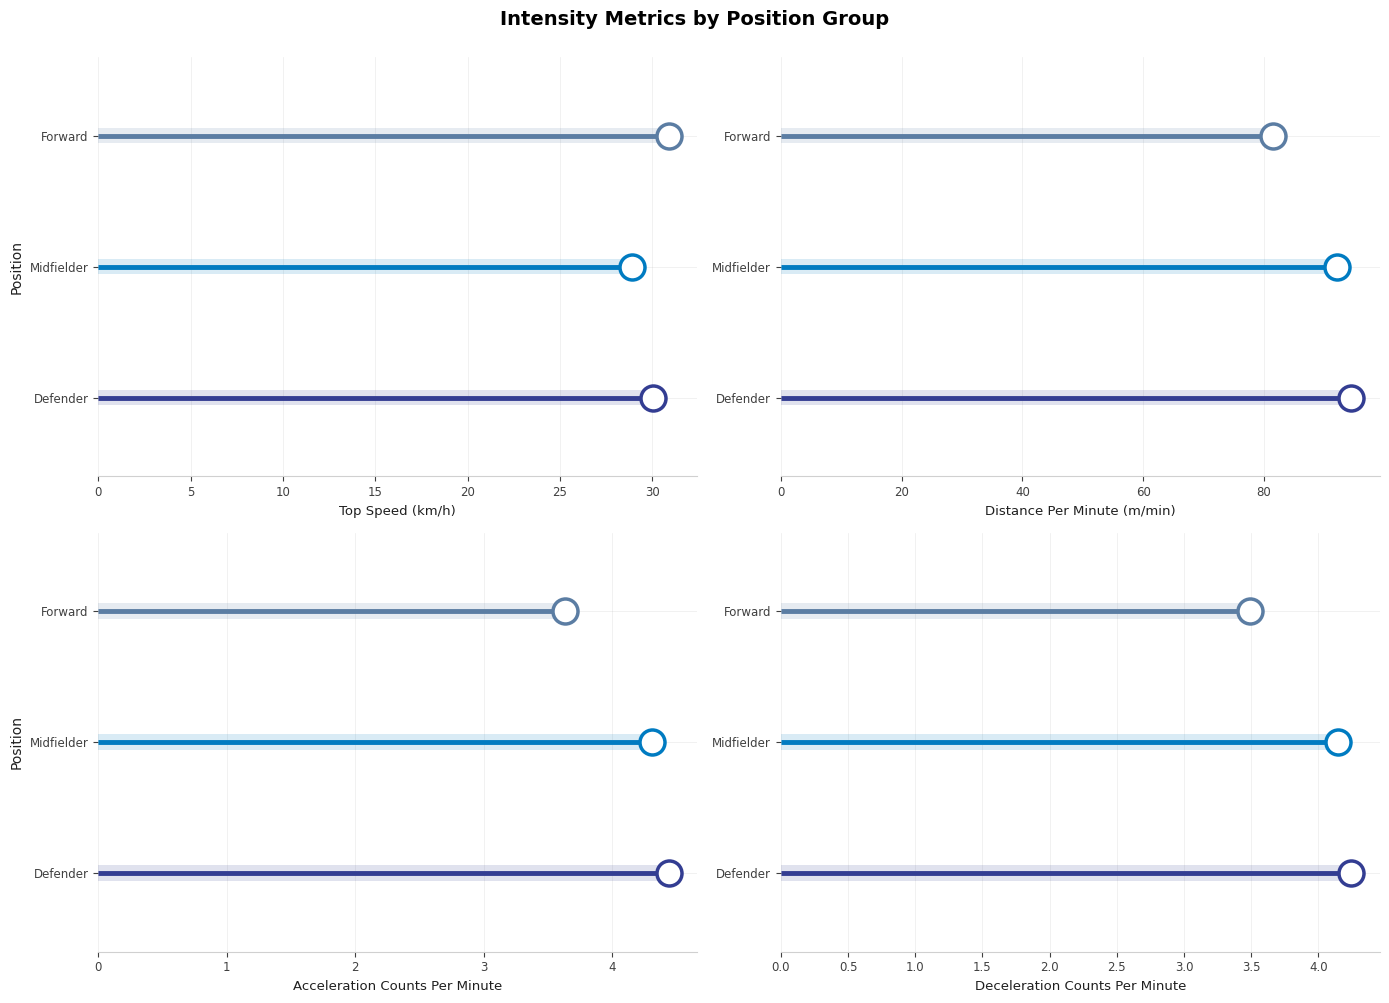

In [41]:
# Professional position group comparison - Intensity metrics with creative styling
metrics_to_plot = [
    ('top_speed_kmh', 'Top Speed (km/h)'),
    ('distance_per_min_mmin', 'Distance Per Minute (m/min)'),
    ('acc_counts_per_min', 'Acceleration Counts Per Minute'),
    ('dec_counts_per_min', 'Deceleration Counts Per Minute')
]

position_order = ['Defender', 'Midfielder', 'Forward']
position_colors = [dark_blue, light_blue, '#5B7DA3']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    
    # Draw horizontal reference lines with gradient colors and creative styling
    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), position_colors):
        # Very thin background bar for context
        ax.barh(y, val, left=0, height=0.12, color=color, alpha=0.15, edgecolor='none')
        # Main line - thicker and more prominent
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=3.5)
        # Large hollow marker with border - no text
        ax.plot(val, y, 'o', color=color, markersize=18, markeredgewidth=2.5, 
               markerfacecolor='white', markeredgecolor=color, zorder=3)
    
    # Format axis - professional typography
    ax.set_yticks(y_positions)
    ax.set_yticklabels(position_order, fontsize=10, fontweight='500')
    ax.set_xlabel(xlabel, fontsize=10, fontweight='500', color='#1F1F1F')
    
    # Apply FUFA theme
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', linestyle='-', alpha=0.15, color='#808080', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.set_ylim(-0.6, n - 0.4)

axes[0, 0].set_ylabel('Position', fontsize=10, fontweight='500', color='#1F1F1F')
axes[1, 0].set_ylabel('Position', fontsize=10, fontweight='500', color='#1F1F1F')

fig.suptitle('Intensity Metrics by Position Group', fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()


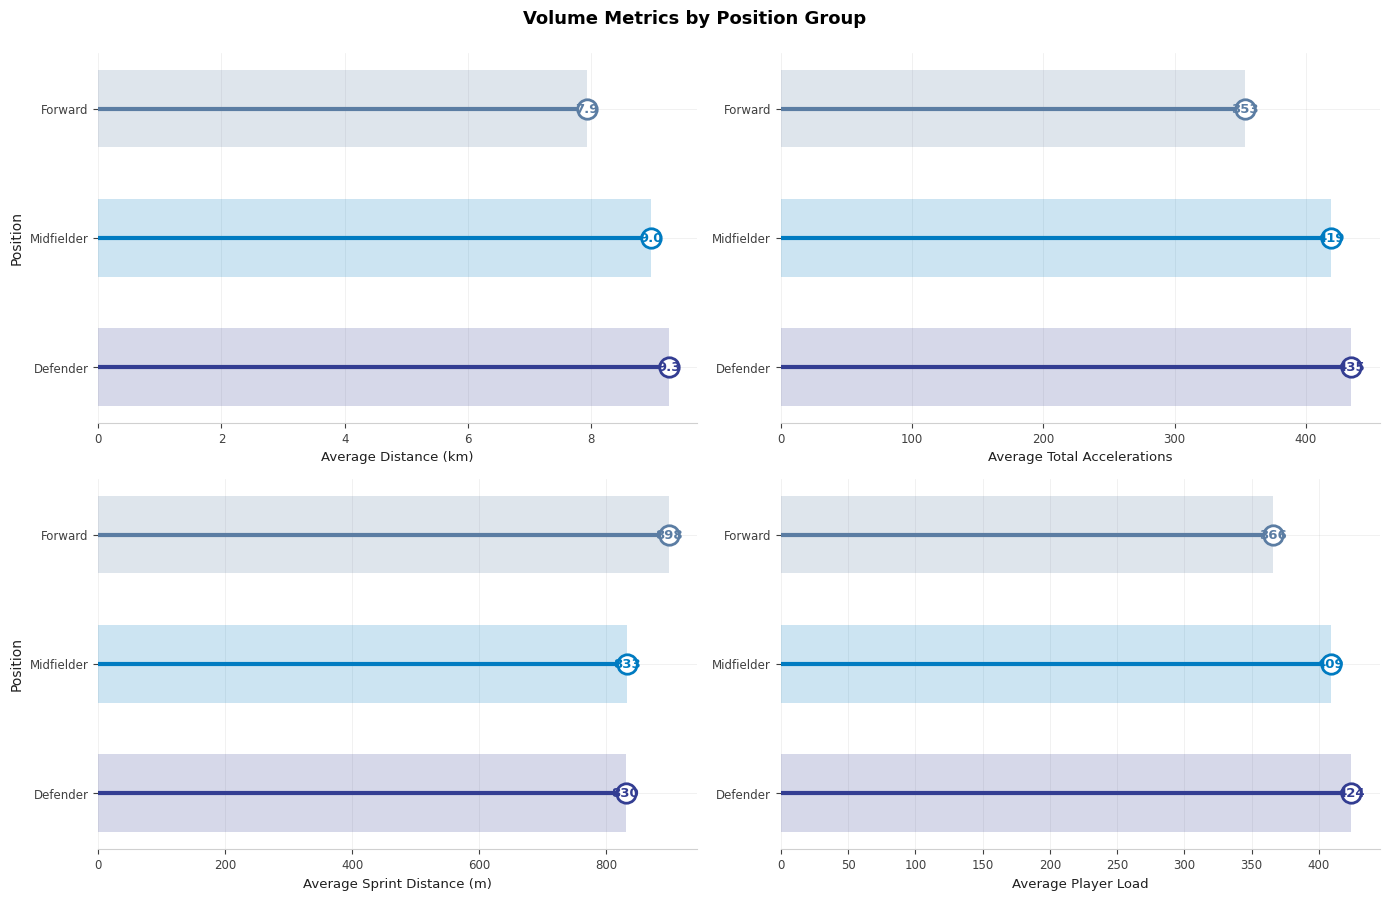

In [42]:
# Professional position group comparison - Volume metrics with creative styling
metrics_to_plot = [
    ('distance_km', 'Average Distance (km)'),
    ('total_accelerations', 'Average Total Accelerations'),
    ('sprint_distance_m', 'Average Sprint Distance (m)'),
    ('player_load', 'Average Player Load')
]

position_order = ['Defender', 'Midfielder', 'Forward']
position_colors = [dark_blue, light_blue, '#5B7DA3']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor='white')

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    
    # Draw horizontal reference lines with gradient colors and creative styling
    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), position_colors):
        # Light background bar for context
        ax.barh(y, val, left=0, height=0.6, color=color, alpha=0.2, edgecolor='none')
        # Main line - thicker
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=3)
        # Large hollow marker with border
        ax.plot(val, y, 'o', color=color, markersize=14, markeredgewidth=2, 
               markerfacecolor='white', markeredgecolor=color, zorder=3)
        
        # Format text based on metric
        if metric == 'distance_km':
            text_val = f'{val:.1f}'
        elif metric == 'sprint_distance_m':
            text_val = f'{val:.0f}'
        elif metric == 'player_load':
            text_val = f'{val:.0f}'
        else:
            text_val = f'{val:.0f}'
        
        ax.text(val, y, text_val, va='center', ha='center', fontsize=9.5, 
                color=color, fontweight='700', zorder=4)
    
    # Format axis - professional typography
    ax.set_yticks(y_positions)
    ax.set_yticklabels(position_order, fontsize=9, fontweight='400')
    ax.set_xlabel(xlabel, fontsize=10, fontweight='400', color='#1F1F1F')
    
    # Apply FUFA theme
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', linestyle='-', alpha=0.15, color='#808080', linewidth=0.5)
    ax.set_axisbelow(True)

axes[0, 0].set_ylabel('Position', fontsize=10, fontweight='400', color='#1F1F1F')
axes[1, 0].set_ylabel('Position', fontsize=10, fontweight='400', color='#1F1F1F')

fig.suptitle('Volume Metrics by Position Group', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Comparison by Location

In [43]:
# # Calculate average volume metrics by location
# avg_volume_by_location = df.groupby('location')[volume_metrics].mean().round(2)
# # style_table_for_docs(avg_volume_by_location)

In [44]:
# # Calculate average intensity metrics by location
# avg_intensity_by_location = df.groupby('location')[[i for i in intensity_metrics ]].mean()
# style_table_for_docs(avg_intensity_by_location)

In [45]:
# # Calculate max metrics by location
# avg_intensity_by_location_ = df.groupby('location')[['top_speed_kmh','distance_per_min_mmin']].max().round(2)
# style_table_for_docs(avg_intensity_by_location_)

In [46]:
# def plot_home_away_top_speed(avg_volume_by_location, color='#003b59', min_radius=0.8, max_radius=1.1):
#     """
#     Plot a semicircle comparison of top speed (km/h) for Home vs Away using avg_volume_by_location DataFrame.
#     """
#     home_speed = avg_volume_by_location.loc['Home', 'distance_km']
#     away_speed = avg_volume_by_location.loc['Away', 'distance_km']

#     speeds = np.array([home_speed, away_speed])
#     norm_radii = min_radius + (speeds - speeds.min()) / (speeds.max() - speeds.min()) * (max_radius - min_radius)
#     home_radius, away_radius = norm_radii

#     fig, ax = plt.subplots(figsize=(3, 3))
#     ax.set_aspect('equal')
#     ax.axis('off')

#     # Draw right (Home) semicircle
#     theta_home = np.linspace(-np.pi/2, np.pi/2, 100)
#     x_home = home_radius * np.cos(theta_home)
#     y_home = home_radius * np.sin(theta_home)
#     ax.plot(x_home, y_home, color=color, linewidth=0.5)
#     if home_radius < away_radius:
#         ax.fill_betweenx(y_home, 0, x_home, color=color, alpha=0.5)

#     # Draw left (Away) semicircle
#     theta_away = np.linspace(np.pi/2, 3*np.pi/2, 100)
#     x_away = away_radius * np.cos(theta_away)
#     y_away = away_radius * np.sin(theta_away)
#     ax.plot(x_away, y_away, color=color, linewidth=0.5)
#     if away_radius < home_radius:
#         ax.fill_betweenx(y_away, x_away, 0, color=color, alpha=0.5)

#     # Draw the separating line
#     ax.plot([0, 0], [-max(home_radius+0.5, away_radius+0.5), max(home_radius+0.5, away_radius+0.5)], color=color, linewidth=0.5, zorder=3)

#     # Place values inside semicircles
#     ax.text(home_radius * 0.5, 0, f"{home_speed:.2f}\nHome", ha='center', va='center', fontsize=10, color='#fff', fontweight='normal')
#     ax.text(-away_radius * 0.5, 0, f"{away_speed:.2f}\nAway", ha='center', va='center', fontsize=10, color='#000', fontweight='normal')

#     plt.title('Distance (km)', fontsize=12)
#     plt.show()
# plot_home_away_top_speed(avg_volume_by_location)

### Metric Distribution 

In [47]:
derived_metrics = ['total_accelerations','total_decelerations','acc_counts_per_min','dec_counts_per_min']
for i in derived_metrics:
    num_cols.append(i)

In [48]:
num_cols.remove('max_acceleration_mss')
num_cols.remove('max_deceleration_mss')

In [49]:
num_cols.remove('duration')

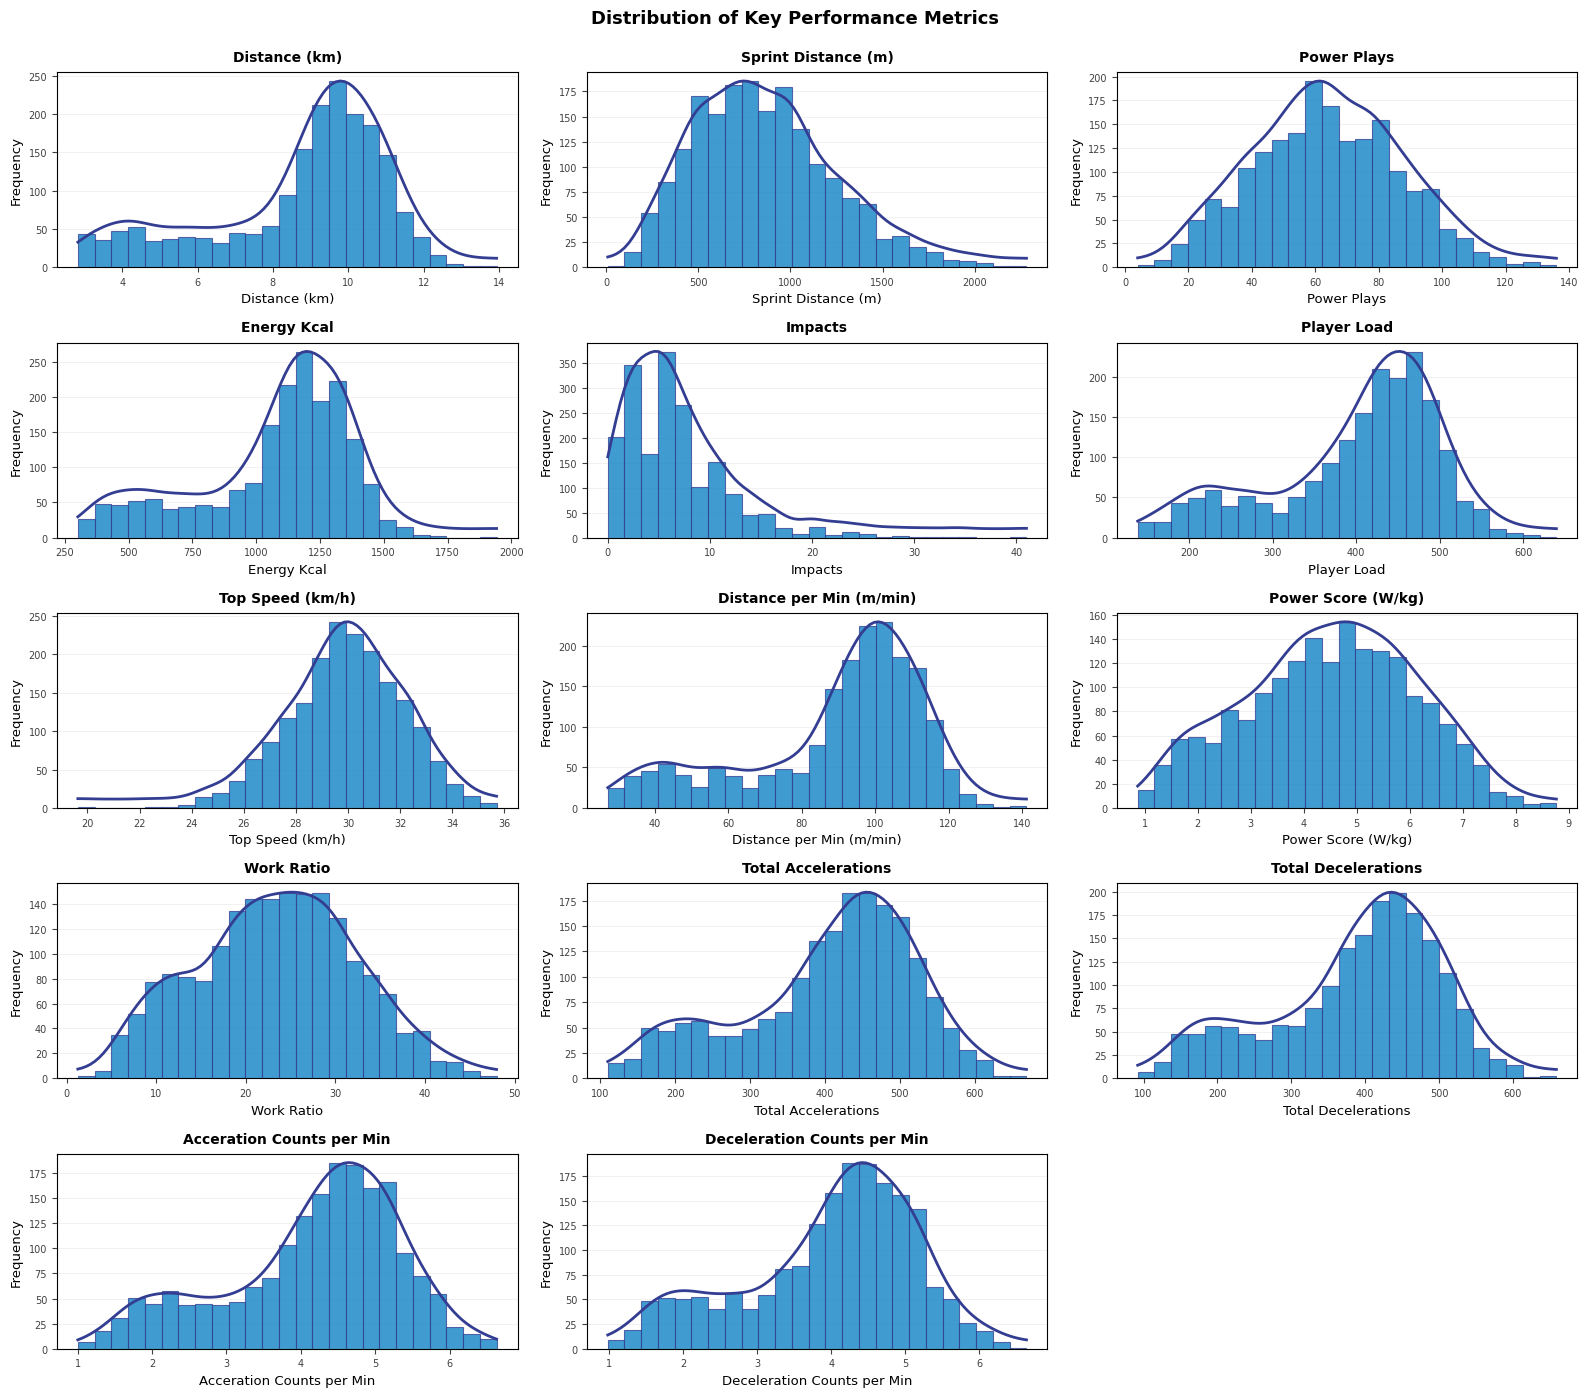

In [50]:
plt.figure(figsize=(16, 14), facecolor='white')

for i, col in enumerate(num_cols):
    ax = plt.subplot(5, 3, i + 1)
    
    # Create histogram with FUFA colors
    n, bins, patches = ax.hist(df[col].dropna(), bins=25, color=light_blue, alpha=0.75, 
                               edgecolor=dark_blue, linewidth=0.8)
    
    # Add KDE line in dark blue
    from scipy import stats
    kde = stats.gaussian_kde(df[col].dropna())
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax2 = ax.twinx()
    ax2.plot(x_range, kde(x_range), color=dark_blue, linewidth=2, label='Density')
    ax2.set_ylabel('')
    ax2.set_yticks([])
    
    # Format title and x-label
    label = col.replace('_', ' ').title()
    if col == 'distance_km':
        label = 'Distance (km)'
    elif col == 'sprint_distance_m':
        label = 'Sprint Distance (m)'
    elif col == 'top_speed_kmh':
        label = 'Top Speed (km/h)'
    elif col == 'distance_per_min_mmin':
        label = 'Distance per Min (m/min)'
    elif col == 'power_score_wkg':
        label = 'Power Score (W/kg)'
    elif col == 'total_decelerations':
        label = 'Total Decelerations'
    elif col == 'total_accelerations':
        label = 'Total Accelerations'
    elif col == 'acc_counts_per_min':
        label = 'Acceration Counts per Min'
    elif col == 'dec_counts_per_min':
        label = 'Deceleration Counts per Min'
    
    ax.set_title(f'{label}', fontsize=10, fontweight='600', pad=8)
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    
    # Apply professional styling
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    ax.tick_params(labelsize=7)

plt.suptitle('Distribution of Key Performance Metrics', fontsize=13, fontweight='700', y=0.995)
plt.tight_layout()
plt.show()


## Trend Analysis

In [51]:
avg_volume_per_matchday = df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
# Ensure 'match_day' is a categorical variable with the correct order
avg_volume_per_matchday['match_day'] = pd.Categorical(
    avg_volume_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
avg_volume_per_matchday = avg_volume_per_matchday.sort_values(by='match_day').round(2)
style_table_for_docs(avg_volume_per_matchday)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,8.900000,863.860000,65.590000,1092.340000,7.040000,419.730000,403.270000,409.180000,29.830000,91.470000,4.850000,24.980000,5.910000,7.250000,4.310000,4.140000
7,Md2,9.370000,979.240000,69.100000,1148.220000,6.870000,434.360000,415.830000,426.700000,30.080000,97.270000,5.150000,26.760000,5.900000,7.370000,4.500000,4.310000
8,Md3,9.160000,914.180000,63.700000,1121.730000,6.800000,422.560000,405.790000,414.190000,29.920000,93.660000,4.350000,22.890000,5.870000,7.520000,4.320000,4.150000
9,Md4,8.390000,842.600000,60.070000,1030.710000,6.610000,390.970000,375.920000,385.500000,30.030000,85.300000,4.310000,22.250000,5.870000,7.370000,3.980000,3.820000
10,Md5,8.670000,830.450000,63.530000,1068.380000,6.250000,411.860000,397.390000,398.100000,29.510000,89.330000,4.230000,21.560000,5.800000,7.250000,4.240000,4.090000
11,Md6,8.480000,853.360000,63.060000,1041.660000,6.170000,382.830000,366.970000,384.180000,29.930000,88.170000,4.270000,22.000000,5.770000,7.190000,3.980000,3.820000
12,Md7,8.760000,834.120000,64.270000,1084.540000,6.490000,413.300000,398.590000,402.800000,29.860000,89.420000,4.700000,24.350000,5.830000,7.200000,4.220000,4.070000
13,Md8,8.860000,812.960000,61.950000,1090.760000,5.270000,408.590000,391.590000,402.180000,29.750000,91.350000,4.770000,25.040000,5.910000,7.250000,4.220000,4.040000
14,Md9,8.580000,817.410000,60.950000,1066.340000,6.870000,391.030000,375.040000,393.600000,30.160000,87.790000,4.150000,21.570000,5.990000,7.090000,4.010000,3.840000
1,Md10,8.840000,865.220000,64.040000,1096.730000,7.650000,413.250000,394.710000,413.540000,30.010000,90.230000,4.680000,24.010000,5.860000,7.230000,4.220000,4.030000


In [52]:
# Sort by match_day using the correct order
df['match_day'] = pd.Categorical(df['match_day'], categories=matchday_order, ordered=True)
df_sorted = df.sort_values('match_day')

# Compute rolling mean for each metric per match day
rolling_avg = (
    df_sorted.groupby('match_day', observed=True)[volume_metrics + intensity_metrics]
    .mean()
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

rolling_avg['match_day'] = pd.Categorical(rolling_avg['match_day'], categories=matchday_order, ordered=True)
rolling_avg = rolling_avg.sort_values(by='match_day').round(2)
style_table_for_docs(rolling_avg)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,8.900000,863.860000,65.590000,1092.340000,7.040000,419.730000,403.270000,409.180000,29.830000,91.470000,4.850000,24.980000,5.910000,7.250000,4.310000,4.140000
1,Md2,9.130000,921.550000,67.340000,1120.280000,6.960000,427.050000,409.550000,417.940000,29.960000,94.370000,5.000000,25.870000,5.900000,7.310000,4.410000,4.230000
2,Md3,9.140000,919.090000,66.130000,1120.760000,6.900000,425.550000,408.290000,416.690000,29.940000,94.130000,4.780000,24.880000,5.890000,7.380000,4.380000,4.200000
3,Md4,8.970000,912.010000,64.290000,1100.220000,6.760000,415.960000,399.180000,408.790000,30.010000,92.070000,4.600000,23.970000,5.880000,7.420000,4.270000,4.100000
4,Md5,8.740000,862.410000,62.430000,1073.610000,6.550000,408.460000,393.030000,399.260000,29.820000,89.430000,4.300000,22.230000,5.840000,7.380000,4.180000,4.020000
5,Md6,8.510000,842.140000,62.220000,1046.910000,6.340000,395.220000,380.090000,389.260000,29.830000,87.600000,4.270000,21.940000,5.810000,7.270000,4.070000,3.910000
6,Md7,8.640000,839.310000,63.620000,1064.860000,6.300000,402.660000,387.650000,395.030000,29.770000,88.970000,4.400000,22.640000,5.800000,7.210000,4.150000,3.990000
7,Md8,8.700000,833.480000,63.090000,1072.320000,5.980000,401.570000,385.710000,396.390000,29.850000,89.650000,4.580000,23.800000,5.840000,7.210000,4.140000,3.970000
8,Md9,8.730000,821.500000,62.390000,1080.540000,6.210000,404.310000,388.400000,399.530000,29.920000,89.520000,4.540000,23.650000,5.910000,7.180000,4.150000,3.980000
9,Md10,8.760000,831.860000,62.310000,1084.610000,6.600000,404.290000,387.110000,403.110000,29.970000,89.790000,4.530000,23.540000,5.920000,7.190000,4.150000,3.970000


In [53]:
# fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# metrics = [
#     ('distance_km', 'Distance (km)'),
#     ('sprint_distance_m', 'Sprint Distance (m)'),
#     ('player_load', 'Player Load'),
#     ('top_speed_kmh', 'Top Speed (km/h)')
# ]

# # Get valid match days (non-NaN)
# valid_matchdays = rolling_avg['match_day'].dropna().tolist()
# MD11_idx = valid_matchdays.index('MD11') if 'MD11' in valid_matchdays else None
# last_idx = len(valid_matchdays) - 1

# for ax, (col, label) in zip(axes.flatten(), metrics):
#     sns.lineplot(
#         data=rolling_avg,
#         x='match_day',
#         y=col,
#         marker='o',
#         ax=ax,
#         label=f'Average {label}'
#     )
#     avg_value = rolling_avg[col].mean()
#     ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
#     # Draw vertical line at MD11
#     ax.axvline(MD11_idx, color='black', linestyle=':', linewidth=1)
#     # Shade area before MD11 (First Round)
#     ax.axvspan(-0.5, MD11_idx - 0.5, color='skyblue', alpha=0.35)
#     # Shade area from MD11 to last matchday (Second Round)
#     ax.axvspan(MD11_idx - 0.5, last_idx + 0.5, color='lightgreen', alpha=0.35)
#     xticklabels = [str(Wmd).replace('MD', 'MD ') for Wmd in valid_matchdays]
#     ax.set_xticks(range(len(valid_matchdays)))
#     ax.set_xticklabels(xticklabels, rotation=90)
#     ax.set_title(f'{label} Across Match Days')
#     ax.set_xlabel('Match Day')
#     ax.set_ylabel(label)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     legend = ax.legend(frameon=False)
#     ymin, ymax = ax.get_ylim()
#     ax.text(MD11_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
#     ax.text(MD11_idx + (last_idx-MD11_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)

# plt.tight_layout(rect=[0, 0.01, 1, 1])
# plt.figtext(0.5, 0.01, "Note: All values are from a 3-match rolling average.", ha='center', fontsize=12, style='italic')
# plt.show()


## Correlation Analysis

In [54]:
# cols_to_corr = [col for col in num_cols if col != 'duration']
# cols_to_corr.extend(['acc_counts_per_min','dec_counts_per_min','total_accelerations','total_decelerations'])
# corr = df[cols_to_corr].corr(method='pearson')

# # Mapping for pretty axis labels
# pretty_labels = {
#     'distance_km': 'Distance (km)',
#     'sprint_distance_m': 'Sprint Distance (m)',
#     'power_plays': 'Power Plays',
#     'energy_kcal': 'Energy (kcal)',
#     'impacts': 'Impacts',
#     'player_load': 'Player Load',
#     'top_speed_kmh': 'Top Speed (km/h)',
#     'distance_per_min_mmin': 'Distance per Min (m/min)',
#     'power_score_wkg': 'Power Score (W/kg)',
#     'work_ratio': 'Work Ratio',
#     'max_acceleration_mss': 'Max Acceleration (m/s²)',
#     'max_deceleration_mss': 'Max Deceleration (m/s²)',
#     'acc_counts_per_min':'Acc. Counts per Min',
#     'dec_counts_per_min':'Dec. Counts per Min',
#     'total_accelerations': 'Total Accelerations',
#     'total_decelerations': 'Total Decelerations'
# }

# # Re-label the correlation matrix
# corr = corr.rename(index=pretty_labels, columns=pretty_labels)

# mask = np.triu(np.ones_like(corr, dtype=bool))

# fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
# sns.heatmap(
#     corr,
#     annot=True,
#     cmap='RdBu_r',
#     center=0,
#     vmin=-1, vmax=1,
#     fmt='.2f',
#     linewidths=0.5,
#     linecolor='white',
#     mask=mask,
#     cbar_kws={'label': 'Correlation Coefficient'},
#     ax=ax,
#     annot_kws={'fontsize': 7, 'fontweight': 'bold'}
# )

# ax.set_title('Correlation Matrix of Key Performance Metrics', fontsize=12, fontweight='700', pad=15)
# ax.set_xlabel('')
# ax.set_ylabel('')
# plt.xticks(fontsize=8, rotation=45, ha='right')
# plt.yticks(fontsize=8, rotation=0)
# plt.tight_layout()
# plt.show()


In [55]:
# fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), facecolor='white')

# # Plot 1: All players, no hue
# ax1 = axes[0]
# ax1.scatter(df['distance_km'], df['sprint_distance_m'], alpha=0.4, color=light_blue, s=30, edgecolors='none')

# # Add regression line in dark blue
# from scipy import stats as sp_stats
# z = np.polyfit(df['distance_km'].dropna(), df.loc[df['distance_km'].notna(), 'sprint_distance_m'], 1)
# p = np.poly1d(z)
# x_line = np.linspace(df['distance_km'].min(), df['distance_km'].max(), 100)
# ax1.plot(x_line, p(x_line), color=dark_blue, linewidth=2.5, label='Trend')

# ax1.set_xlabel('Distance (km)', fontsize=10, fontweight='600')
# ax1.set_ylabel('Sprint Distance (m)', fontsize=10, fontweight='600')
# ax1.set_title('All Players', fontsize=11, fontweight='600')
# apply_fufa_chart_theme(ax1)

# # Plot 2: Hue by player position with trend lines
# ax2 = axes[1]
# position_colors_dict = {'Defenders': dark_blue, 'Midfielders': light_blue, 'Forwards': '#5B7DA3'}

# for pos in df['general_position'].dropna().unique():
#     data_subset = df[df['general_position'] == pos]
#     ax2.scatter(data_subset['distance_km'], data_subset['sprint_distance_m'], 
#                alpha=0.3, color=position_colors_dict.get(pos, dark_blue), s=30, 
#                label=pos, edgecolors='none')
    
#     # Add trend line for each position
#     if len(data_subset) > 1:
#         z = np.polyfit(data_subset['distance_km'].dropna(), 
#                       data_subset.loc[data_subset['distance_km'].notna(), 'sprint_distance_m'], 1)
#         p = np.poly1d(z)
#         x_line = np.linspace(data_subset['distance_km'].min(), data_subset['distance_km'].max(), 50)
#         ax2.plot(x_line, p(x_line), color=position_colors_dict.get(pos, dark_blue), 
#                 linewidth=2.5, linestyle='-', alpha=0.8)

# ax2.set_xlabel('Distance (km)', fontsize=10, fontweight='600')
# ax2.set_ylabel('Sprint Distance (m)', fontsize=10, fontweight='600')
# ax2.set_title('By Player Position', fontsize=11, fontweight='600')
# apply_fufa_chart_theme(ax2)
# ax2.legend(title='Position', frameon=True, fancybox=False, shadow=False, fontsize=9, title_fontsize=9)

# fig.suptitle('Distance vs Sprint Distance Relationship', fontsize=12, fontweight='700', y=1.00)
# plt.tight_layout()
# plt.show()


## Other Requests

### Pairwise Performance

In [56]:
# # Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

# clubs = sorted(df['club_for'].unique())
# single_matchday_metric = []

# for i, club1 in enumerate(clubs):
#     for club2 in clubs[i+1:]:
#         # Find all matchdays where these two clubs played each other
#         matchdays = df[
#             ((df['club_for'] == club1) & (df['club_against'] == club2)) |
#             ((df['club_for'] == club2) & (df['club_against'] == club1))
#         ]['match_day'].unique()
#         for md in matchdays:
#             # Filter for only this pair and this matchday
#             mask = (
#                 (((df['club_for'] == club1) & (df['club_against'] == club2)) |
#                  ((df['club_for'] == club2) & (df['club_against'] == club1))) &
#                 (df['match_day'] == md)
#             )
#             relevant_rows = df[mask]
#             if not relevant_rows.empty:
#                 avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
#                 row = {
#                     'Team A': club1,
#                     'Team B': club2,
#                     'match_day': md
#                 }
#                 row.update(avg_metrics.to_dict())
#                 single_matchday_metric.append(row)

# single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
# single_matchday_metric_df = single_matchday_metric_df[
#     (single_matchday_metric_df['top_speed_kmh'] > 20)
# ][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] > 8)]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] > 300)]
# single_matchday_metric_df = single_matchday_metric_df.sort_values(by='player_load', ascending=False).reset_index(drop=True)

# style_table_for_docs(single_matchday_metric_df.head(10))

In [57]:
# # Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

# clubs = sorted(df['club_for'].unique())
# single_matchday_metric = []

# for i, club1 in enumerate(clubs):
#     for club2 in clubs[i+1:]:
#         # Find all matchdays where these two clubs played each other
#         matchdays = df[
#             ((df['club_for'] == club1) & (df['club_against'] == club2)) |
#             ((df['club_for'] == club2) & (df['club_against'] == club1))
#         ]['match_day'].unique()
#         for md in matchdays:
#             # Filter for only this pair and this matchday
#             mask = (
#                 (((df['club_for'] == club1) & (df['club_against'] == club2)) |
#                  ((df['club_for'] == club2) & (df['club_against'] == club1))) &
#                 (df['match_day'] == md)
#             )
#             relevant_rows = df[mask]
#             if not relevant_rows.empty:
#                 avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
#                 row = {
#                     'Team A': club1,
#                     'Team B': club2,
#                     'match_day': md
#                 }
#                 row.update(avg_metrics.to_dict())
#                 single_matchday_metric.append(row)

# single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
# single_matchday_metric_df = single_matchday_metric_df[
#     (single_matchday_metric_df['top_speed_kmh'] > 0)
# ][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] < 9)]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] < 400)]
# single_matchday_metric_df = single_matchday_metric_df.sort_values(by='distance_km', ascending=True).reset_index(drop=True)

# style_table_for_docs(single_matchday_metric_df.head(10))

In [58]:
# # Create a DataFrame showing the averages of all intensity metrics for each team A when they play team B
# clubs = sorted(df['club_for'].unique())
# avg_intensity_vs_opponent = []

# for club1 in clubs:
#     for club2 in clubs:
#         if club1 == club2:
#             continue  # skip self
#         mask = (
#             ((df['club_for'] == club1) & (df['club_against'] == club2))
#         )
#         club1_rows = df[mask]
#         if not club1_rows.empty:
#             avg_metrics = club1_rows[intensity_metrics].mean()
#             row = {'Team A': club1, 'Team B': club2}
#             row.update(avg_metrics.to_dict())
#             avg_intensity_vs_opponent.append(row)

# avg_intensity_vs_opponent_df = pd.DataFrame(avg_intensity_vs_opponent)
# avg_intensity_vs_opponent_df = avg_intensity_vs_opponent_df.sort_values(by='top_speed_kmh', ascending=False).reset_index(drop=True)
# style_table_for_docs(avg_intensity_vs_opponent_df.head(10))

In [59]:
# # Create a DataFrame showing the averages of all volume metrics for each team A when they play team B
# clubs = sorted(df['club_for'].unique())
# avg_volume_vs_opponent = []

# for club1 in clubs:
#     for club2 in clubs:
#         if club1 == club2:
#             continue  # skip self
#         mask = (
#             ((df['club_for'] == club1) & (df['club_against'] == club2))
#         )
#         club1_rows = df[mask]
#         if not club1_rows.empty:
#             avg_metrics = club1_rows[volume_metrics].mean()
#             row = {'Team A': club1, 'Team B': club2}
#             row.update(avg_metrics.to_dict())
#             avg_volume_vs_opponent.append(row)

# avg_volume_vs_opponent_df = pd.DataFrame(avg_volume_vs_opponent)
# avg_volume_vs_opponent_df = avg_volume_vs_opponent_df.sort_values(by='distance_km', ascending=False).reset_index(drop=True)
# style_table_for_docs(avg_volume_vs_opponent_df.head(10))

### Top Performers for each Metric (Individual/ Team/ Pairwise)

In [60]:
# # Find top 5 players for each metric in volume_metrics and intensity_metrics
# top5_players = []

# metrics_to_check = volume_metrics + intensity_metrics
# for metric in metrics_to_check:
#     # Get top 5 rows for this metric
#     top_rows = df.nlargest(5, metric)
#     for _, row in top_rows.iterrows():
#         top5_players.append({
#             'metric': metric,
#             'player': row['p_name'],
#             'club': row['club_for'],
#             'value': row[metric],
#             'match day': row['match_day']
#         })

# top5_players_df = pd.DataFrame(top5_players)
# # Optionally, sort for display
# top5_players_df = top5_players_df.sort_values(['metric', 'value'], ascending=[True, False]).reset_index(drop=True)
# style_table_for_docs(top5_players_df)

### Best Performers in each position

In [61]:
# # Combine metrics into one list
# all_metrics = volume_metrics + intensity_metrics

# # Store top 5 players per metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     for position in df['general_position'].dropna().unique():
#         # Get top 5 players for this metric and position
#         top_rows = df[df['general_position'] == position].nlargest(5, metric)
        
#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'value': row[metric],
#                 'match day': row['match_day'],
#                 'position': position
#             })

# # Convert to DataFrame
# top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# # Sort by metric name (alphabetically) and then value (descending)
# top5_players_by_position_df = top5_players_by_position_df.sort_values(
#     ['metric', 'value'], ascending=[True, False]
# ).reset_index(drop=True)

# # Apply your styling function
# style_table_for_docs(top5_players_by_position_df)



In [62]:
# # Combine metrics into one list
# all_metrics = volume_metrics + intensity_metrics

# # Group by player and position, then average all metrics
# avg_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].mean().reset_index()

# # Store top 5 players per metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     for position in avg_df['general_position'].dropna().unique():
#         # Get top 5 players for this metric and position
#         top_rows = avg_df[avg_df['general_position'] == position].nlargest(5, metric)
        
#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'value': row[metric],
#                 'position': position
#             })

# # Convert to DataFrame
# top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# # Sort for display: alphabetically by metric, descending by value
# top5_players_by_position_df = top5_players_by_position_df.sort_values(
#     ['metric', 'value'], ascending=[True, False]
# ).reset_index(drop=True)

# # Display nicely (assuming this is your custom function)
# style_table_for_docs(top5_players_by_position_df)


In [63]:
# # Custom position sorting order
# position_order = ['Defenders', 'Midfielders', 'Forwards']

# # Step 1: Count appearances (unique match days)
# appearances_df = df.groupby(['p_name', 'general_position', 'club_for'])['match_day'].nunique().reset_index()
# appearances_df = appearances_df.rename(columns={'match_day': 'appearances'})

# # Step 2: Calculate mean and std for metrics
# metrics_stats_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].agg(['mean', 'std']).reset_index()

# # Step 3: Fix column names: flatten multi-index columns
# metrics_stats_df.columns = [
#     f"{metric}_{stat}" if stat else metric
#     for metric, stat in metrics_stats_df.columns.to_flat_index()
# ]

# # Step 4: Merge with appearances
# merged_df = metrics_stats_df.merge(
#     appearances_df,
#     on=['p_name', 'general_position', 'club_for']
# )

# # Step 5: Only include players with at least 3 appearances
# filtered_df = merged_df[merged_df['appearances'] >= 15]

# # Step 6: Extract top 5 players for each metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     mean_col = f'{metric}_mean'
#     std_col = f'{metric}_std'

#     for position in position_order:
#         group = filtered_df[filtered_df['general_position'] == position]

#         # Skip if metric column is missing
#         if mean_col not in group.columns:
#             continue

#         top_rows = group.nlargest(5, mean_col)

#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'mean_value': row[mean_col],
#                 'std_dev': row[std_col],
#                 'appearances': row['appearances'],
#                 'position': position
#             })

# # Step 7: Create and sort final DataFrame
# top5_df = pd.DataFrame(top5_players_by_position)

# # Sort positions using custom category
# top5_df['position'] = pd.Categorical(
#     top5_df['position'], categories=position_order, ordered=True
# )

# # Sort by metric → position → mean value
# top5_df = top5_df.sort_values(['metric', 'position', 'mean_value'], ascending=[True, True, False]).reset_index(drop=True)

# # Show results
# style_table_for_docs(top5_df.round(2))


## Speed Zones

In [64]:
# # List of speed zone columns
# speed_zone_cols = [
#     'distance_in_speed_zone_1_km',
#     'distance_in_speed_zone_2_km',
#     'distance_in_speed_zone_3_km',
#     'distance_in_speed_zone_4_km',
#     'distance_in_speed_zone_5_km'
# ]

# # Compute average distance for each speed zone
# avg_speed_zone_dist = df[speed_zone_cols].mean()

# # Prepare labels (replace _ with space, add zone number)
# zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

# plt.figure(figsize=(8, 5))


# # Create barplot
# # plt.figure(figsize=(12,6))
# sns.barplot(x=zone_labels,hue=zone_labels, y=avg_speed_zone_dist.values, palette='Blues_d',legend=False)

# # Title, subtitle, and axis labels
# # plt.ylabel("Average Distance (m)")
# plt.xlabel("Speed Zone")
# plt.title("Average Distance(m) Covered in Each Speed Zone (All Players)", pad=30)

# ax= plt.gca()

# # Gridlines for y-axis
# ax.yaxis.grid(True, linestyle='--', alpha=0.5)
# ax.set_axisbelow(True)

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)

# # Annotate values inside bars
# for i, v in enumerate(avg_speed_zone_dist):
#     # Convert km to m and format with comma

#     ax.annotate(
#         f"{int(round(v),):,}",
#         xy=(i, v),
#         xytext=(0, 1),
#         textcoords='offset points',
#         ha='center',
#         va='bottom',
#         fontsize=9,
#         bbox=dict(boxstyle="circle,pad=0.15", edgecolor='#4682B4', facecolor='white', linewidth=1)
#     )

# #remove yaxis ticklabels
# ax.set_yticklabels([])
# ax.set_yticks([])

# plt.show()


C:\Users\Travail\AppData\Local\Temp\ipykernel_2052\606275136.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(zone_labels, fontsize=9, fontweight='400')


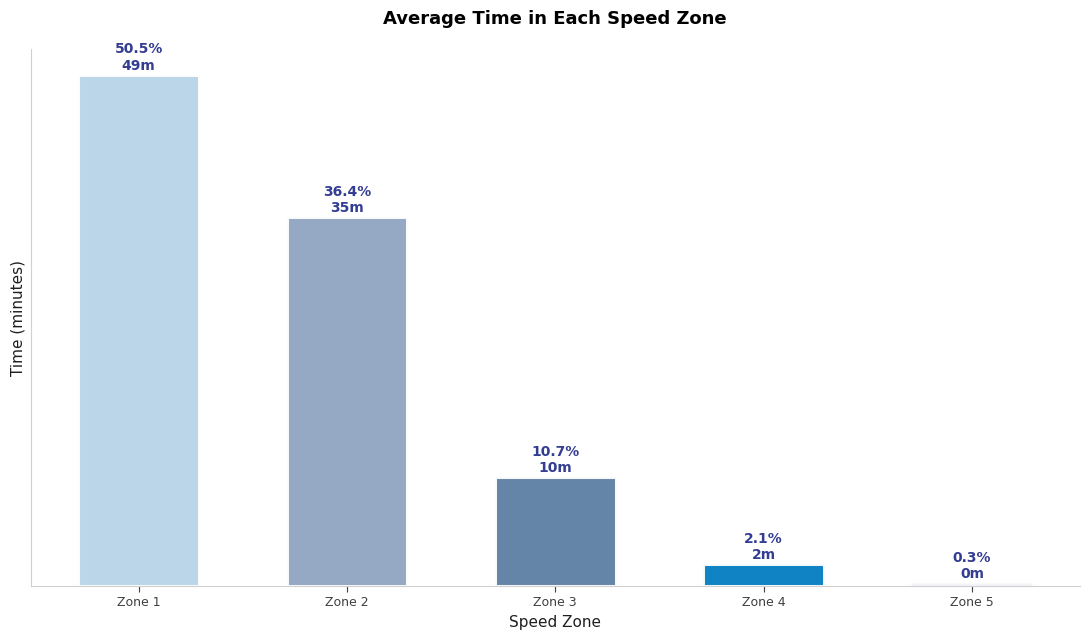

In [65]:
# Speed zones - Time distribution with creative styling
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Compute average time (secs) for each speed zone
avg_time_secs = df[speed_zone_cols].mean()
total_time = avg_time_secs.sum()

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

# Create professional FUFA color gradient from light to dark blue
zone_colors = ['#B8D4E8', '#8FA3C1', '#5B7DA3', light_blue, dark_blue]

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
bars = ax.bar(zone_labels, avg_time_secs.values / 60, color=zone_colors, 
             edgecolor='white', linewidth=2.2, width=0.58, alpha=0.94)

# Apply FUFA theme
apply_fufa_chart_theme(ax, remove_y_ticks=True, remove_y_labels=True)

ax.set_xlabel('Speed Zone', fontsize=11, fontweight='400', color='#1F1F1F')
ax.set_ylabel('Time (minutes)', fontsize=11, fontweight='400', color='#1F1F1F')
ax.set_title('Average Time in Each Speed Zone', fontsize=13, fontweight='bold', pad=18)

# Annotate with percentages and time above bars
for i, secs in enumerate(avg_time_secs):
    pct = (secs / total_time) * 100
    mins = int(secs // 60)
    ax.text(
        i, 
        (secs / 60) + 0.2,
        f'{pct:.1f}%\n{mins}m',
        ha='center', 
        va='bottom', 
        fontsize=10,
        fontweight='600',
        color=dark_blue
    )

# Tick styling
ax.tick_params(axis='x', labelsize=9, colors='#404040', length=4)
ax.set_xticklabels(zone_labels, fontsize=9, fontweight='400')

plt.tight_layout()
plt.show()

In [66]:
# # Stacked bar chart: percentage distance in each speed zone by position (creative styling)
# speed_zone_cols = [
#     'distance_in_speed_zone_1_km',
#     'distance_in_speed_zone_2_km',
#     'distance_in_speed_zone_3_km',
#     'distance_in_speed_zone_4_km',
#     'distance_in_speed_zone_5_km'
# ]

# # Group by position and sum distances
# zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# # Reorder positions
# position_order = ['Defenders', 'Midfielders', 'Forwards']
# zone_by_position = zone_by_position.reindex(position_order)

# # Prepare labels
# zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
# zone_by_position.columns = zone_labels

# # Convert to percentages
# zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# # Create professional FUFA color gradient
# zone_colors_stack = ['#B8D4E8', '#8FA3C1', '#5B7DA3', light_blue, dark_blue]

# fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
# zone_pct.plot(
#     kind='bar',
#     stacked=True,
#     color=zone_colors_stack,
#     ax=ax,
#     edgecolor='white',
#     linewidth=2.2,
#     width=0.58,
#     alpha=0.94,
#     legend=True
# )

# # Annotate values inside segments with improved readability
# for i, pos in enumerate(zone_pct.index):
#     cumulative = 0
#     for j, zone in enumerate(zone_labels):
#         value = zone_pct.loc[pos, zone]
#         if value > 3:  # Only annotate segments larger than 3%
#             y = cumulative + value / 2
#             ax.text(i, y, f'{value:.1f}%', ha='center', va='center', 
#                    fontsize=9.5, color='white', fontweight='600')
#         cumulative += value

# ax.set_xlabel('Position Group', fontsize=11, fontweight='400', color='#1F1F1F')
# ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='400', color='#1F1F1F')
# ax.set_title('Speed Zone Distribution by Position', fontsize=13, fontweight='bold', pad=18)
# ax.set_xticklabels(position_order, rotation=0, fontsize=10, fontweight='400')

# apply_fufa_chart_theme(ax, remove_y_ticks=True, remove_y_labels=True)

# # Format legend
# ax.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.02, 1), 
#          loc='upper left', fontsize=9, title_fontsize=10)

# # Y-axis from 0 to 100%
# ax.set_ylim(0, 100)

# # Tick styling
# ax.tick_params(axis='x', labelsize=9, colors='#404040')
# ax.tick_params(axis='y', labelsize=8, colors='#404040')

# plt.tight_layout()
# plt.show()

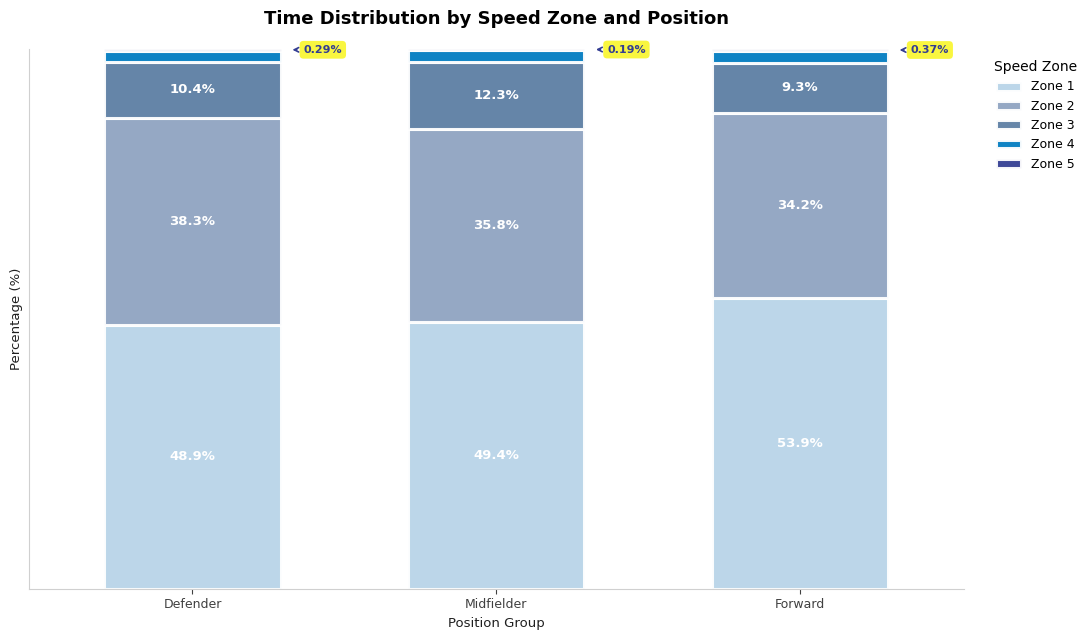

In [67]:
from matplotlib.patches import Patch

# Stacked bar chart: percentage time in each speed zone by position (creative styling)
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Group by position and sum times
zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# Reorder positions
position_order = ['Defender', 'Midfielder', 'Forward']
zone_by_position = zone_by_position.reindex(position_order)

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
zone_by_position.columns = zone_labels

# Convert to percentages
zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# Create professional FUFA color gradient
zone_colors_stack = ['#B8D4E8', '#8FA3C1', '#5B7DA3', light_blue, dark_blue]

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
zone_pct.plot(
    kind='bar',
    stacked=True,
    color=zone_colors_stack,
    ax=ax,
    edgecolor='white',
    linewidth=2.2,
    width=0.58,
    alpha=0.94,
    legend=True
)

# Annotate values with professional styling
for i, pos in enumerate(zone_pct.index):
    cumulative = 0
    for j, zone in enumerate(zone_labels):
        value = zone_pct.loc[pos, zone]
        if value > 4:  # Annotate segments larger than 4%
            y = cumulative + value / 2
            ax.text(i, y, f'{value:.1f}%', ha='center', va='center', 
                   fontsize=9.5, color='white', fontweight='600')
        elif value > 0.1 and zone == 'Zone 5':  # Highlight Zone 5 smaller segments
            y = cumulative + value / 2
            ax.annotate(
                f'{value:.2f}%',
                xy=(i + 0.32, y),
                xytext=(10, 0),
                textcoords='offset points',
                ha='left', va='center',
                fontsize=8, fontweight='600',
                color=dark_blue,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=yellow, 
                         edgecolor='none', alpha=0.75),
                arrowprops=dict(arrowstyle='->', color=dark_blue, lw=1.2)
            )
        cumulative += value

ax.set_xlabel('Position Group', fontsize=11, fontweight='400', color='#1F1F1F')
ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='400', color='#1F1F1F')
ax.set_title('Time Distribution by Speed Zone and Position', fontsize=13, fontweight='bold', pad=18)
ax.set_xticklabels(position_order, rotation=0, fontsize=10, fontweight='400')

apply_fufa_chart_theme(ax, remove_y_ticks=True, remove_y_labels=True)

# Format legend
ax.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.02, 1), 
         loc='upper left', fontsize=9, title_fontsize=10)

# Y-axis from 0 to 100%
ax.set_ylim(0, 100)

# Tick styling
ax.tick_params(axis='x', labelsize=9, colors='#404040')
ax.tick_params(axis='y', labelsize=8, colors='#404040')

plt.tight_layout()
plt.show()

In [68]:
zone_by_position

,Zone 1,Zone 2,Zone 3,Zone 4,Zone 5
general_position,,,,,
Defender,2203235.2,1727688.5,468607.1,92651.1,13062.3
Midfielder,1705313.8,1237083.2,425489.3,77039.6,6685.8
Forward,1659696.0,1053852.4,287700.7,66358.3,11394.2


In [69]:
style_table_for_docs(zone_pct.round(2))

,Zone 1,Zone 2,Zone 3,Zone 4,Zone 5
general_position,,,,,
Defender,48.900000,38.350000,10.400000,2.060000,0.290000
Midfielder,49.410000,35.840000,12.330000,2.230000,0.190000
Forward,53.900000,34.230000,9.340000,2.160000,0.370000


C:\Users\Travail\AppData\Local\Temp\ipykernel_2052\54999305.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.99])


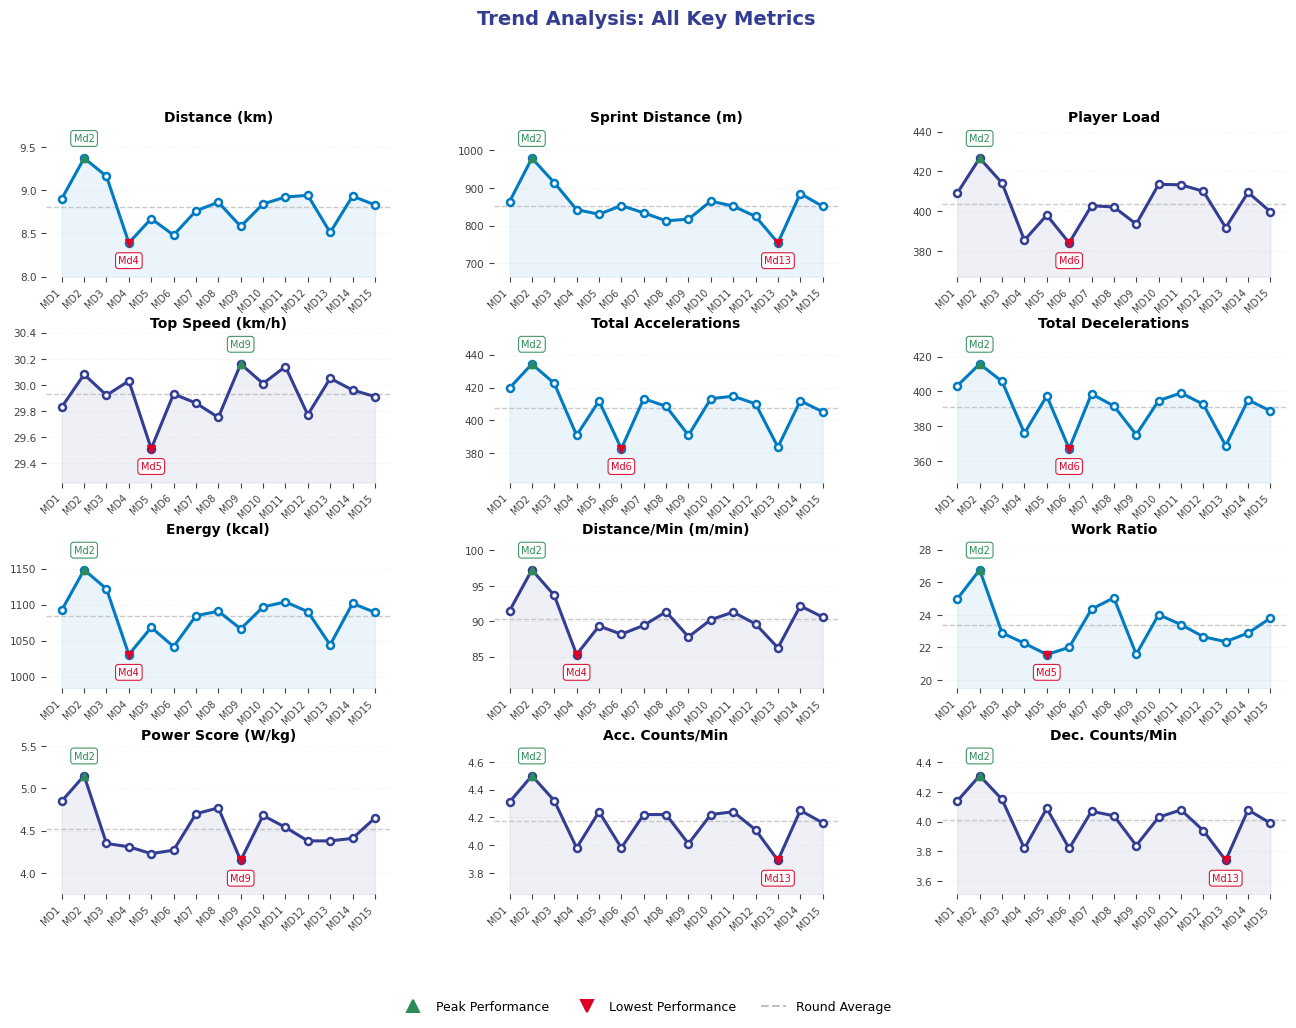

In [70]:
# Create compact multi-metric trend dashboard with improvements
fig = plt.figure(figsize=(16, 10), facecolor='white')
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# Select key metrics (volume + intensity mix)
metrics_to_visualize = [
    ('distance_km', 'Distance (km)', light_blue),
    ('sprint_distance_m', 'Sprint Distance (m)', light_blue),
    ('player_load', 'Player Load', dark_blue),
    ('top_speed_kmh', 'Top Speed (km/h)', dark_blue),
    ('total_accelerations', 'Total Accelerations', light_blue),
    ('total_decelerations', 'Total Decelerations', light_blue),
    ('energy_kcal', 'Energy (kcal)', light_blue),
    ('distance_per_min_mmin', 'Distance/Min (m/min)', dark_blue),
    ('work_ratio', 'Work Ratio', light_blue),
    ('power_score_wkg', 'Power Score (W/kg)', dark_blue),
    ('acc_counts_per_min', 'Acc. Counts/Min', dark_blue),
    ('dec_counts_per_min', 'Dec. Counts/Min', dark_blue)
]

for idx, (metric, label, color) in enumerate(metrics_to_visualize):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    
    # Get data sorted by matchday
    data = avg_volume_per_matchday[['match_day', metric]].copy()
    data = data.dropna()
    
    # Set y-axis limits to exclude 0 and reduce thickness
    min_val = data[metric].min()
    max_val = data[metric].max()
    y_range = max_val - min_val
    y_min = max(0, min_val - 0.40 * y_range)  # Add 5% padding below minimum
    y_max = max_val + 0.4 * y_range  # Add 10% padding above maximum
    ax.set_ylim(y_min, y_max)
    
    # Plot line with markers
    ax.plot(range(len(data)), data[metric].values, 
           marker='o', color=color, linewidth=2.2, markersize=5,
           markerfacecolor='white', markeredgecolor=color, markeredgewidth=1.8, zorder=2)
    
    # Add subtle fill under curve (reduced opacity)
    ax.fill_between(range(len(data)), y_min, data[metric].values, alpha=0.08, color=color)
    
    # average line
    avg_val = data[metric].mean()
    ax.axhline(avg_val, color='#A9A9A9', linestyle='--', linewidth=1, alpha=0.6, zorder=1)
    
    # Apply FUFA theme
    apply_fufa_chart_theme(ax, remove_y_labels=False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Compact styling
    ax.set_title(label, fontsize=10, fontweight='600', color=black, pad=2)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels([f'MD{i+1}' for i in range(len(data))], fontsize=7, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=7.5)
    ax.grid(axis='y', linestyle=':', alpha=0.2, linewidth=0.5)
    
    # Find min/max with their indices
    min_idx_pos = data[metric].idxmin()
    max_idx_pos = data[metric].idxmax()
    min_val_data = data.loc[min_idx_pos, metric]
    max_val_data = data.loc[max_idx_pos, metric]
    
    min_x_pos = list(data.index).index(min_idx_pos)
    max_x_pos = list(data.index).index(max_idx_pos)
    
    # Add min/max markers with MD labels
    ax.plot(min_x_pos, min_val_data, 'v', color=red, markersize=6, zorder=3)
    ax.plot(max_x_pos, max_val_data, '^', color='#2E8B57', markersize=6, zorder=3)
    
    # Annotate min/max with match day labels
    min_md = data.iloc[min_x_pos]['match_day']
    max_md = data.iloc[max_x_pos]['match_day']
    
    ax.annotate(f'{min_md}', xy=(min_x_pos, min_val_data), xytext=(0, -15),
               textcoords='offset points', ha='center', fontsize=7, fontweight='500',
               color=red, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                   edgecolor=red, linewidth=0.8, alpha=0.9))
    
    ax.annotate(f'{max_md}', xy=(max_x_pos, max_val_data), xytext=(0, 12),
               textcoords='offset points', ha='center', fontsize=7, fontweight='500',
               color='#2E8B57', bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                        edgecolor='#2E8B57', linewidth=0.8, alpha=0.9))

fig.suptitle('Trend Analysis: All Key Metrics', 
            fontsize=14, fontweight='bold', y=0.995, color=dark_blue)

# Add legend in a dedicated area at the bottom
legend_elements = [
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#2E8B57', 
              markersize=8, label='Peak Performance', markeredgecolor='#2E8B57', markeredgewidth=1.5),
    plt.Line2D([0], [0], marker='v', color='w', markerfacecolor=red, 
              markersize=8, label='Lowest Performance', markeredgecolor=red, markeredgewidth=1.5),
    plt.Line2D([0], [0], color='#A9A9A9', linestyle='--', linewidth=1.5, 
              label='Round Average', alpha=0.7)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
          fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()